# Memory-Efficient Fashion Recommendation System

This project builds a personalized fashion recommendation pipeline using the H&M Personalized Fashion Recommendations dataset. The goal is to generate Top-5 product recommendations for each customer while keeping the workflow memory-efficient and reproducible.

## Project Overview

The notebook covers three main datasets:

* `articles.csv`: product metadata, including product type, color, department, and garment group information
* `customers.csv`: customer-level information
* `transactions_train.csv`: historical purchase records used for feature engineering and model training

The analysis includes data overview, missing value checks, feature engineering, candidate generation, machine learning-based ranking, and Top-K recommendation evaluation.

## Key Features

* Memory-efficient data loading with chunked reading
* Customer-level feature engineering
* Candidate generation for customer-product pairs
* Machine learning models for purchase prediction and ranking
* Top-5 personalized recommendations
* Evaluation using MAP@5 and HitRate@5

## Configuration

* `TOPK = 5`: number of recommendations per customer
* `CAND_PER_USER = 150`: maximum candidate items per customer
* `NEG_PER_USER = 30`: number of negative samples per customer
* `ACTIVE_WEEKS = 8`: recent activity window for filtering active customers
* `TRAIN_WEEKS = 26`: training window for feature engineering
* `SEED = 42`: random seed for reproducibility


In [1]:
# Global Configuration

TOPK = 5
CAND_PER_USER = 150
NEG_PER_USER = 30

ACTIVE_WEEKS = 8
TRAIN_WEEKS = 26

SEED = 42
CHUNK_SIZE = 500000

import numpy as np
import random

np.random.seed(SEED)
random.seed(SEED)

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import random

# Project paths
BASE_DIR = Path(".")
DATA_DIR = Path.home() / "Desktop"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "report_figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

# Global configuration
TOPK = 5
CAND_PER_USER = 150
NEG_PER_USER = 30

ACTIVE_WEEKS = 8
TRAIN_WEEKS = 26

SEED = 42
CHUNK_SIZE = 500000

np.random.seed(SEED)
random.seed(SEED)

d:\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Overview Articles Dataset


In [3]:
# Load articles dataset
articles_path = DATA_DIR / "articles.csv"

df_articles = pd.read_csv(articles_path)
df_ar = df_articles  # Alias for compatibility with later notebook cells

df_articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


## Overview Customers Dataset


In [4]:
# Load customers dataset
customers_path = DATA_DIR / "customers.csv"

df_customer = pd.read_csv(customers_path)
df_customers = df_customer  # Alias for compatibility if later cells use df_customers

df_customer.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


## Analyzing Transactions Dataset

**Note**: This is a large file (~3.2GB). The analysis uses chunked reading for full file statistics.


In [5]:
# Load transactions dataset
transactions_path = DATA_DIR / "transactions_train.csv"

# Read first 100,000 rows for initial analysis
df_txn = pd.read_csv(transactions_path, nrows=100000)

# Alias for compatibility with later notebook cells
df_sample = df_txn

print(f"Analyzing file: transactions_train.csv")
print(f"Sample data shape: {df_sample.shape[0]:,} rows × {df_sample.shape[1]} columns")

df_txn.head()

Analyzing file: transactions_train.csv
Sample data shape: 100,000 rows × 5 columns


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


### Full File Statistics (Chunked Reading)

**Warning**: This may take several minutes to complete as it reads the entire 3.2GB file in chunks.


In [6]:
# Full file statistics using chunked reading
print("=" * 80)
print("Full File Statistics Using Chunked Reading")
print("=" * 80)

transactions_path = DATA_DIR / "transactions_train.csv"

total_rows = 0
unique_customers = set()
unique_articles = set()
total_amount = 0

for chunk in pd.read_csv(transactions_path, chunksize=CHUNK_SIZE):
    total_rows += len(chunk)
    unique_customers.update(chunk["customer_id"].unique())
    unique_articles.update(chunk["article_id"].unique())
    total_amount += chunk["price"].sum()

print("\nFull File Statistics:")
print(f"Total transactions: {total_rows:,}")
print(f"Unique customers: {len(unique_customers):,}")
print(f"Unique articles: {len(unique_articles):,}")
print(f"Total transaction amount: ${total_amount:,.2f}")
print(f"Average transaction amount: ${total_amount / total_rows:.4f}")

Full File Statistics Using Chunked Reading

Full File Statistics:
Total transactions: 31,788,324
Unique customers: 1,362,281
Unique articles: 104,547
Total transaction amount: $884,645.97
Average transaction amount: $0.0278


# Visualize Distributions of Features and Outcomes

This section creates visualizations to understand the distributions of features and outcomes in the dataset.

## Objectives
- Plot outcome distributions (outcome_user, purchase counts)
- Plot feature distributions for customer features
- Plot feature distributions for article features (using transaction samples)

In [8]:
from datetime import timedelta
import matplotlib.pyplot as plt

# Compute cutoff date
max_date = None

for chunk in pd.read_csv(transactions_path, usecols=["t_dat"], chunksize=CHUNK_SIZE):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])
    chunk_max = chunk["t_dat"].max()
    
    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

cutoff_date = max_date - timedelta(days=7)
target_start = cutoff_date
target_end = max_date

print(f"Max date in dataset: {max_date.date()}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Target window: {target_start.date()} to {target_end.date()}")

# Compute outcome_user
target_transactions = []

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "t_dat"],
    chunksize=CHUNK_SIZE
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])
    
    target_chunk = chunk[
        (chunk["t_dat"] >= target_start) &
        (chunk["t_dat"] <= target_end)
    ]
    
    if len(target_chunk) > 0:
        target_transactions.append(target_chunk)

if target_transactions:
    target_df = pd.concat(target_transactions, ignore_index=True)
    outcome_user_df = (
        target_df.groupby("customer_id")
        .size()
        .reset_index(name="purchase_count")
    )
    outcome_user_df["outcome_user"] = (
        outcome_user_df["purchase_count"] >= 1
    ).astype(int)
else:
    outcome_user_df = pd.DataFrame(
        columns=["customer_id", "purchase_count", "outcome_user"]
    )

# Merge with customer data
df_customers_baseline = df_customer[["customer_id"]].merge(
    outcome_user_df[["customer_id", "outcome_user"]],
    on="customer_id",
    how="left"
).fillna({"outcome_user": 0})

print("\nOutcome distribution:")
print(f"Customers with outcome_user=1: {df_customers_baseline['outcome_user'].sum():,.0f}")
print(f"Customers with outcome_user=0: {(df_customers_baseline['outcome_user'] == 0).sum():,.0f}")
print(f"Positive rate: {df_customers_baseline['outcome_user'].mean() * 100:.2f}%")

Max date in dataset: 2020-09-22
Cutoff date: 2020-09-15
Target window: 2020-09-15 to 2020-09-22

Outcome distribution:
Customers with outcome_user=1: 75,481
Customers with outcome_user=0: 1,296,499
Positive rate: 5.50%


## 1. Outcome Distributions


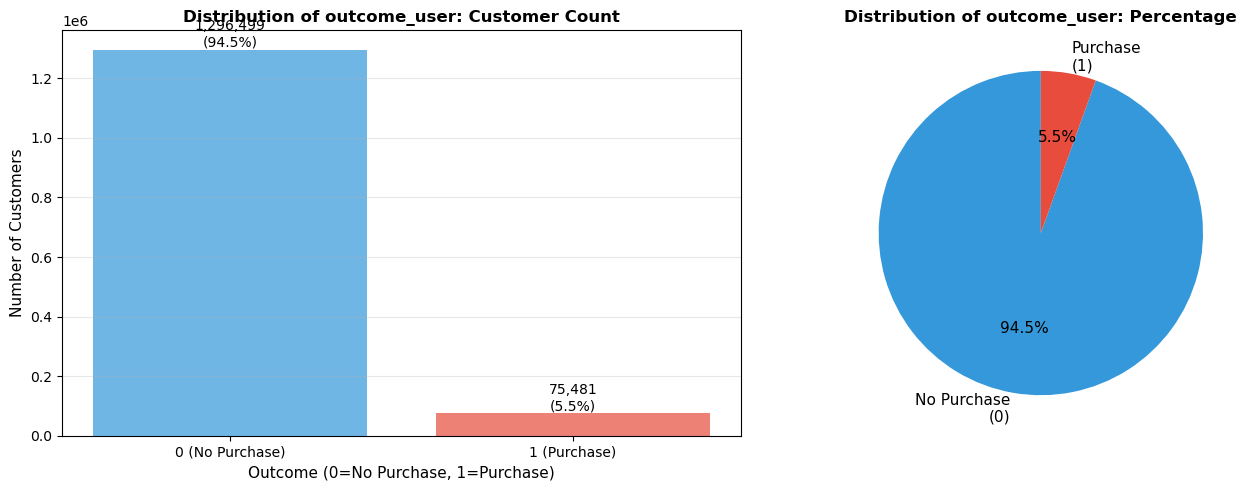


Summary:
  Total customers: 1,371,980
  Customers with purchases (outcome=1): 75,481 (5.50%)
  Customers without purchases (outcome=0): 1,296,499 (94.50%)
  Class imbalance ratio: 17.18:1


In [9]:
# Plot 1: Distribution of outcome_user (binary classification target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Count of customers by outcome
outcome_counts = df_customers_baseline['outcome_user'].value_counts().sort_index()
outcome_percentages = (outcome_counts / len(df_customers_baseline) * 100).round(2)

axes[0].bar(outcome_counts.index, outcome_counts.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_xlabel('Outcome (0=No Purchase, 1=Purchase)', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_title('Distribution of outcome_user: Customer Count', fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (No Purchase)', '1 (Purchase)'])
for i, (idx, count) in enumerate(outcome_counts.items()):
    axes[0].text(idx, count, f'{count:,}\n({outcome_percentages[idx]:.1f}%)',
                ha='center', va='bottom', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart: Percentage distribution
axes[1].pie(outcome_counts.values, labels=['No Purchase\n(0)', 'Purchase\n(1)'],
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Distribution of outcome_user: Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Total customers: {len(df_customers_baseline):,}")
print(f"  Customers with purchases (outcome=1): {outcome_counts.get(1, 0):,} ({outcome_percentages.get(1, 0):.2f}%)")
print(f"  Customers without purchases (outcome=0): {outcome_counts.get(0, 0):,} ({outcome_percentages.get(0, 0):.2f}%)")
print(f"  Class imbalance ratio: {outcome_counts.get(0, 1) / outcome_counts.get(1, 1):.2f}:1")


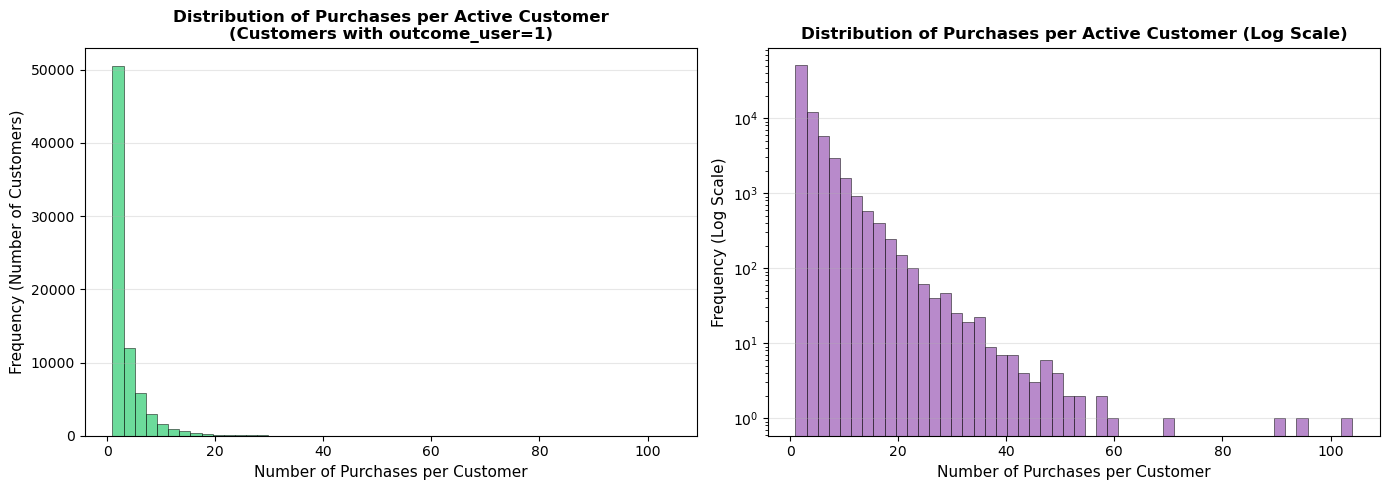


Summary for active customers (outcome_user=1):
  Number of active customers: 75,481
  Mean purchases per customer: 3.53
  Median purchases per customer: 2.00
  Max purchases per customer: 104
  Min purchases per customer: 1


In [10]:
# Plot 2: Distribution of purchases per active customer (for customers with outcome_user=1)
if outcome_user_df is not None and len(outcome_user_df) > 0:
    active_customers = outcome_user_df[outcome_user_df['purchase_count'] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram: Purchases per active customer
    purchase_counts = active_customers['purchase_count'].values
    axes[0].hist(purchase_counts, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel('Number of Purchases per Customer', fontsize=11)
    axes[0].set_ylabel('Frequency (Number of Customers)', fontsize=11)
    axes[0].set_title('Distribution of Purchases per Active Customer\n(Customers with outcome_user=1)',
                      fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # Log-scale histogram to better see the tail
    axes[1].hist(purchase_counts, bins=50, color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Number of Purchases per Customer', fontsize=11)
    axes[1].set_ylabel('Frequency (Log Scale)', fontsize=11)
    axes[1].set_title('Distribution of Purchases per Active Customer (Log Scale)',
                      fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nSummary for active customers (outcome_user=1):")
    print(f"  Number of active customers: {len(active_customers):,}")
    print(f"  Mean purchases per customer: {purchase_counts.mean():.2f}")
    print(f"  Median purchases per customer: {np.median(purchase_counts):.2f}")
    print(f"  Max purchases per customer: {purchase_counts.max():,}")
    print(f"  Min purchases per customer: {purchase_counts.min():,}")
else:
    print("No active customers found for visualization")


## 3. Feature Distributions: Article Features (from Transaction Samples)


Sampling transactions from last 8 weeks for price distribution...


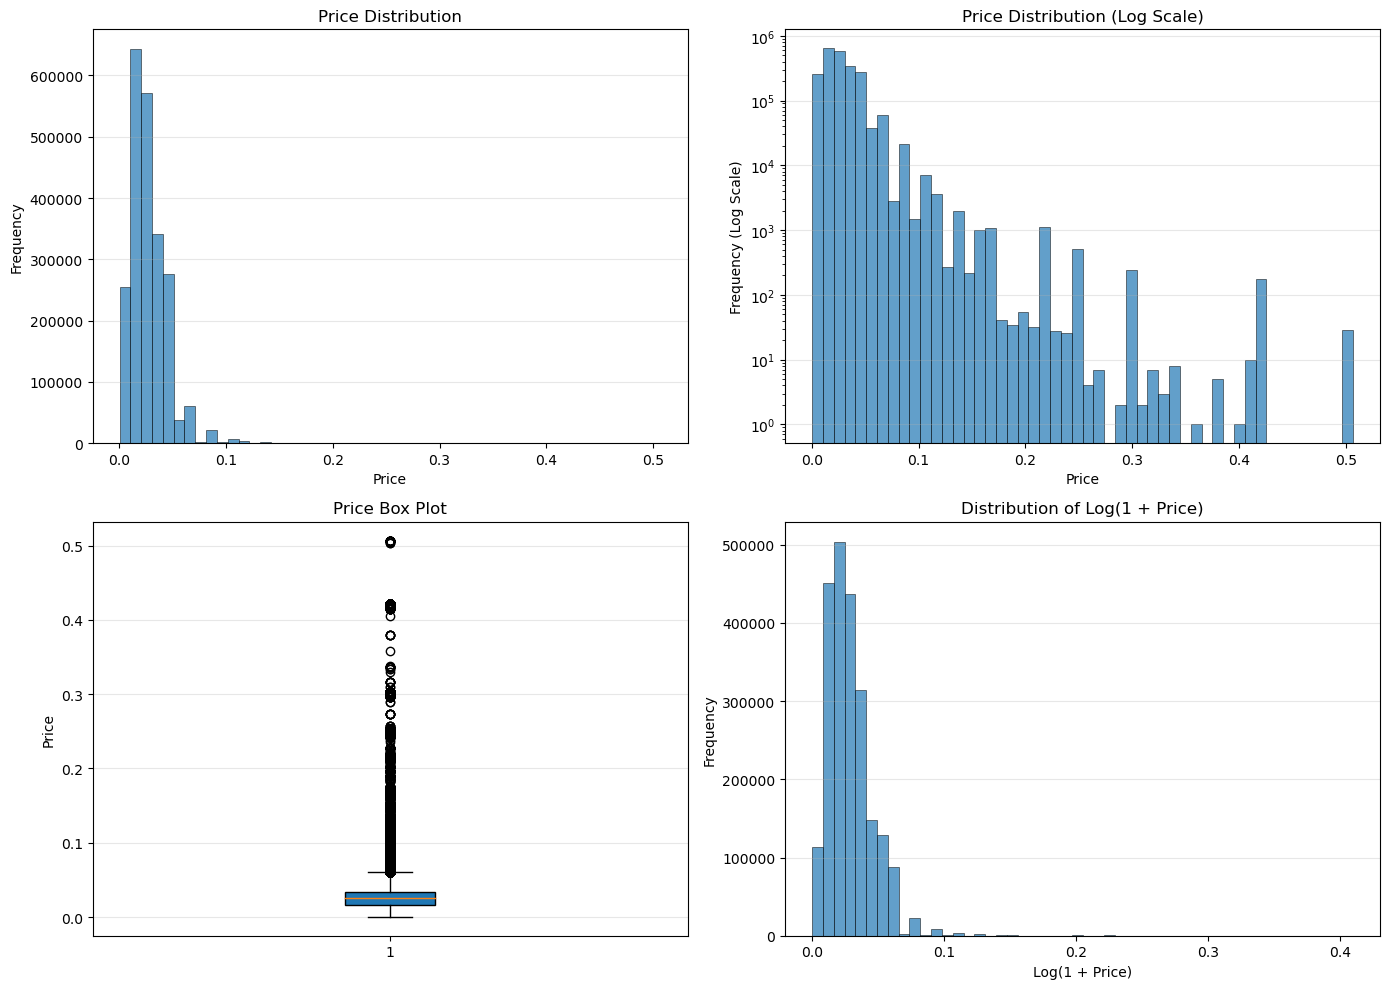


Price Statistics:
Sampled transactions: 2,227,906
Mean price: $0.0277
Median price: $0.0254
Min price: $0.0002
Max price: $0.5068
Standard deviation: $0.0190


In [11]:
# Plot 3: Price distribution from recent transaction samples
print("Sampling transactions from last 8 weeks for price distribution...")

cutoff_sample = cutoff_date - timedelta(days=56)
price_samples = []
sample_count = 0
sample_limit = 2_000_000

for chunk in pd.read_csv(
    transactions_path,
    usecols=["price", "t_dat"],
    chunksize=CHUNK_SIZE
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])
    recent_chunk = chunk[chunk["t_dat"] >= cutoff_sample]

    if len(recent_chunk) > 0:
        price_samples.append(recent_chunk[["price"]])
        sample_count += len(recent_chunk)

    if sample_count >= sample_limit:
        break

if price_samples:
    price_df = pd.concat(price_samples, ignore_index=True)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(price_df["price"], bins=50, alpha=0.7, edgecolor="black", linewidth=0.5)
    axes[0, 0].set_xlabel("Price")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].set_title("Price Distribution")
    axes[0, 0].grid(axis="y", alpha=0.3)

    axes[0, 1].hist(price_df["price"], bins=50, alpha=0.7, edgecolor="black", linewidth=0.5)
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xlabel("Price")
    axes[0, 1].set_ylabel("Frequency (Log Scale)")
    axes[0, 1].set_title("Price Distribution (Log Scale)")
    axes[0, 1].grid(axis="y", alpha=0.3)

    axes[1, 0].boxplot(price_df["price"], vert=True, patch_artist=True)
    axes[1, 0].set_ylabel("Price")
    axes[1, 0].set_title("Price Box Plot")
    axes[1, 0].grid(axis="y", alpha=0.3)

    axes[1, 1].hist(np.log1p(price_df["price"]), bins=50, alpha=0.7, edgecolor="black", linewidth=0.5)
    axes[1, 1].set_xlabel("Log(1 + Price)")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_title("Distribution of Log(1 + Price)")
    axes[1, 1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nPrice Statistics:")
    print(f"Sampled transactions: {len(price_df):,}")
    print(f"Mean price: ${price_df['price'].mean():.4f}")
    print(f"Median price: ${price_df['price'].median():.4f}")
    print(f"Min price: ${price_df['price'].min():.4f}")
    print(f"Max price: ${price_df['price'].max():.4f}")
    print(f"Standard deviation: ${price_df['price'].std():.4f}")
else:
    print("No price data available for visualization.")

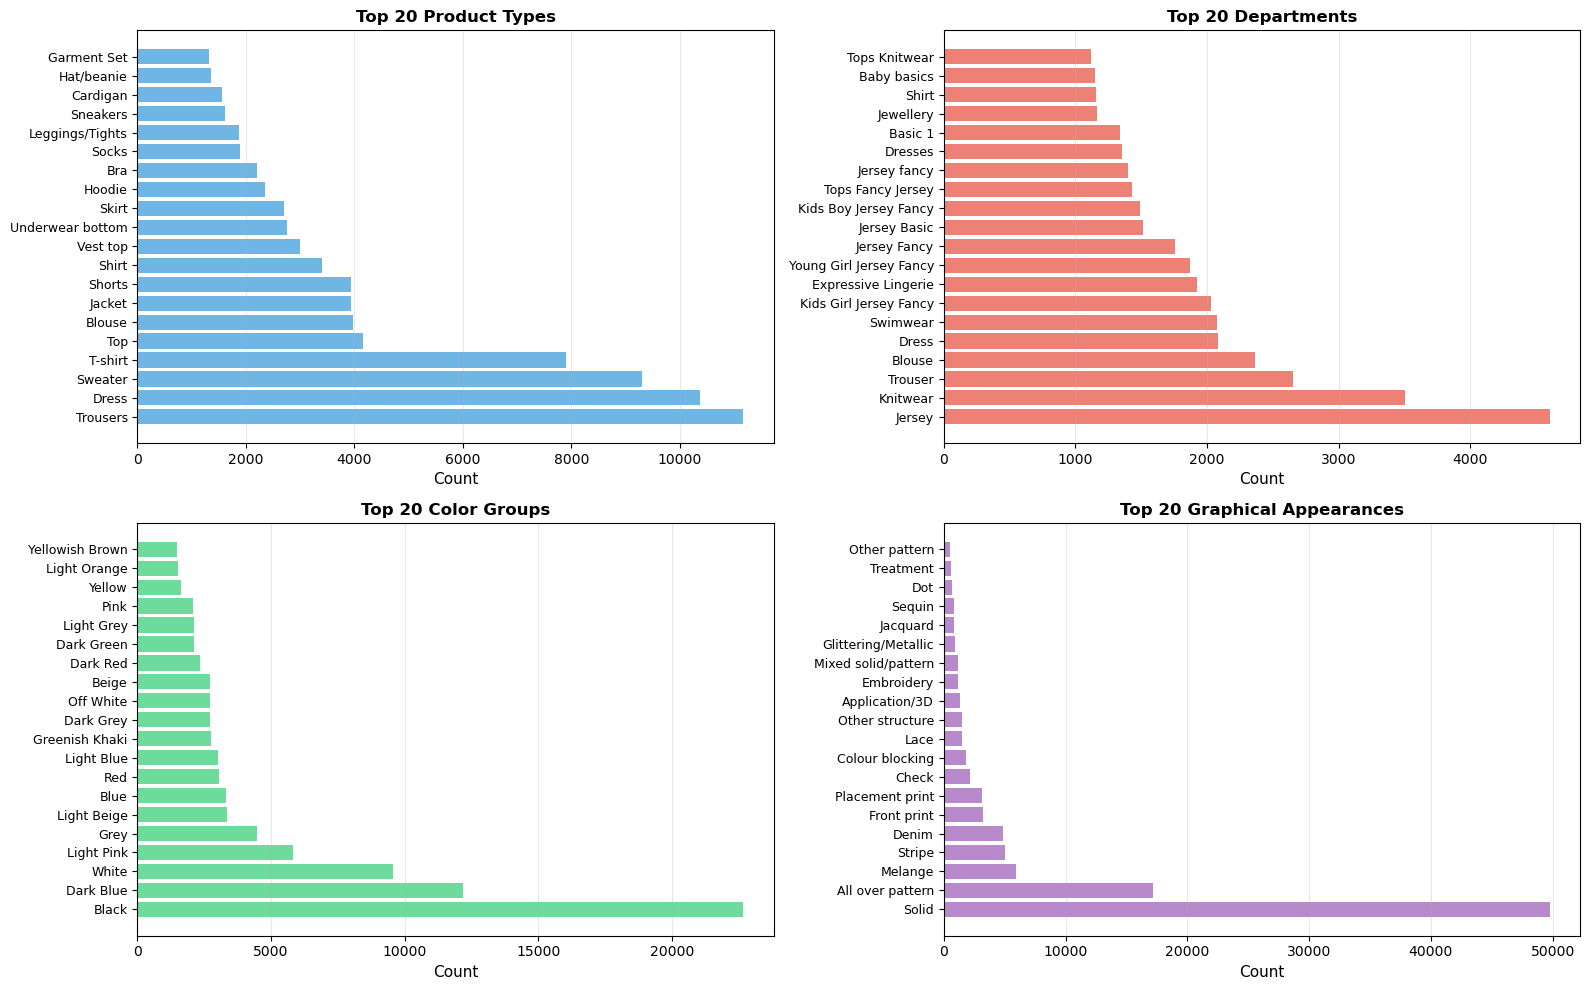

In [12]:
# Plot 4: Top Product Types / Departments / Colors from Articles
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Product Type Distribution
# MODIFIED: Ensure df_articles exists (use df_ar if needed)
try:
    _ = df_articles
except NameError:
    df_articles = df_ar

if 'product_type_name' in df_articles.columns:
    top_product_types = df_articles['product_type_name'].value_counts().head(20)
    axes[0, 0].barh(range(len(top_product_types)), top_product_types.values, color='#3498db', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_product_types)))
    axes[0, 0].set_yticklabels(top_product_types.index, fontsize=9)
    axes[0, 0].set_xlabel('Count', fontsize=11)
    axes[0, 0].set_title('Top 20 Product Types', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'product_type_name not available', ha='center', va='center', fontsize=12)
    axes[0, 0].set_title('Top 20 Product Types', fontsize=12, fontweight='bold')

# Department Distribution
if 'department_name' in df_articles.columns:
    top_departments = df_articles['department_name'].value_counts().head(20)
    axes[0, 1].barh(range(len(top_departments)), top_departments.values, color='#e74c3c', alpha=0.7)
    axes[0, 1].set_yticks(range(len(top_departments)))
    axes[0, 1].set_yticklabels(top_departments.index, fontsize=9)
    axes[0, 1].set_xlabel('Count', fontsize=11)
    axes[0, 1].set_title('Top 20 Departments', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'department_name not available', ha='center', va='center', fontsize=12)
    axes[0, 1].set_title('Top 20 Departments', fontsize=12, fontweight='bold')

# Color Group Distribution
if 'colour_group_name' in df_articles.columns:
    top_colors = df_articles['colour_group_name'].value_counts().head(20)
    axes[1, 0].barh(range(len(top_colors)), top_colors.values, color='#2ecc71', alpha=0.7)
    axes[1, 0].set_yticks(range(len(top_colors)))
    axes[1, 0].set_yticklabels(top_colors.index, fontsize=9)
    axes[1, 0].set_xlabel('Count', fontsize=11)
    axes[1, 0].set_title('Top 20 Color Groups', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'colour_group_name not available', ha='center', va='center', fontsize=12)
    axes[1, 0].set_title('Top 20 Color Groups', fontsize=12, fontweight='bold')

# Graphical Appearance Distribution
if 'graphical_appearance_name' in df_articles.columns:
    top_appearance = df_articles['graphical_appearance_name'].value_counts().head(20)
    axes[1, 1].barh(range(len(top_appearance)), top_appearance.values, color='#9b59b6', alpha=0.7)
    axes[1, 1].set_yticks(range(len(top_appearance)))
    axes[1, 1].set_yticklabels(top_appearance.index, fontsize=9)
    axes[1, 1].set_xlabel('Count', fontsize=11)
    axes[1, 1].set_title('Top 20 Graphical Appearances', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'graphical_appearance_name not available', ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('Top 20 Graphical Appearances', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


---

# Setup: Cutoff Date and Outcome Definition

Before building models, we need to define the prediction problem:
- Set a cutoff date T = max_date - 7 days
- Define outcome_user = 1 if customer has ≥1 purchase in (T, T+7 days], else 0

In [13]:
# Compute cutoff date and outcome_user for validation
from datetime import timedelta

print("Computing cutoff date and outcome_user...")

# Get the latest transaction date using chunked reading
max_date = None

for chunk in pd.read_csv(
    transactions_path,
    usecols=["t_dat"],
    chunksize=CHUNK_SIZE
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])
    chunk_max = chunk["t_dat"].max()

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

cutoff_date = max_date - timedelta(days=7)
target_start = cutoff_date
target_end = max_date

print(f"Max date in dataset: {max_date.date()}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Target window: {target_start.date()} to {target_end.date()}")

# Compute outcome_user:
# outcome_user = 1 if a customer has at least one purchase in the target window
target_transactions = []

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "t_dat"],
    chunksize=CHUNK_SIZE
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    target_chunk = chunk[
        (chunk["t_dat"] > target_start) &
        (chunk["t_dat"] <= target_end)
    ]

    if len(target_chunk) > 0:
        target_transactions.append(target_chunk)

if target_transactions:
    target_df = pd.concat(target_transactions, ignore_index=True)
    outcome_user_df = (
        target_df.groupby("customer_id")
        .size()
        .reset_index(name="purchase_count")
    )
    outcome_user_df["outcome_user"] = (
        outcome_user_df["purchase_count"] >= 1
    ).astype(int)
else:
    outcome_user_df = pd.DataFrame(
        columns=["customer_id", "purchase_count", "outcome_user"]
    )

# Merge outcome labels with all customers
df_customers_baseline = df_customer[["customer_id"]].merge(
    outcome_user_df[["customer_id", "outcome_user"]],
    on="customer_id",
    how="left"
).fillna({"outcome_user": 0})

print("\nOutcome distribution:")
print(
    f"Customers with outcome_user=1: "
    f"{df_customers_baseline['outcome_user'].sum():,.0f} "
    f"({df_customers_baseline['outcome_user'].mean() * 100:.2f}%)"
)
print(
    f"Customers with outcome_user=0: "
    f"{(df_customers_baseline['outcome_user'] == 0).sum():,.0f} "
    f"({(df_customers_baseline['outcome_user'] == 0).mean() * 100:.2f}%)"
)
print(
    f"Majority class: "
    f"{0 if df_customers_baseline['outcome_user'].mean() < 0.5 else 1}"
)

Computing cutoff date and outcome_user...
Max date in dataset: 2020-09-22
Cutoff date: 2020-09-15
Target window: 2020-09-15 to 2020-09-22

Outcome distribution:
Customers with outcome_user=1: 68,984 (5.03%)
Customers with outcome_user=0: 1,302,996 (94.97%)
Majority class: 0


---

# Customer Feature Engineering and Preprocessing


## Selected Features

We will use the following features to predict `outcome_user` (whether a customer makes a purchase in the target window):

1. **Historical Purchase Frequency** (`total_purchases`): Total number of purchases before cutoff date
2. **Average Transaction Value** (`avg_price`): Average price per transaction
3. **Total Spending** (`total_spent`): Total amount spent before cutoff date
4. **Recency** (`days_since_last_purchase`): Days since last purchase before cutoff
5. **Customer Age** (`age_normalized`): Customer age (normalized)
6. **Club Member Status** (`is_active_member`): Binary indicator for active membership
7. **Purchase Recency Score** (`purchase_recency_score`): Recency score based on recent purchase activity

All features will be computed from transactions **before** the cutoff date to avoid data leakage.

In [14]:
# Customer-level feature engineering from historical transactions

print("=" * 80)
print("Customer Feature Engineering and Preprocessing")
print("=" * 80)

print("\nExtracting customer-level features from historical transactions before cutoff date...")

customer_features_list = []
chunk_count = 0

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "article_id", "price", "t_dat"],
    chunksize=CHUNK_SIZE
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    # Use only transactions before the cutoff date to avoid data leakage
    train_chunk = chunk[chunk["t_dat"] < cutoff_date]

    if len(train_chunk) > 0:
        customer_stats = (
            train_chunk
            .groupby("customer_id")
            .agg(
                total_purchases=("article_id", "count"),
                total_spent=("price", "sum"),
                last_purchase_date=("t_dat", "max")
            )
            .reset_index()
        )

        customer_features_list.append(customer_stats)

    chunk_count += 1

# Combine customer features across chunks
if customer_features_list:
    customer_features_train = pd.concat(customer_features_list, ignore_index=True)

    customer_features_train = (
        customer_features_train
        .groupby("customer_id")
        .agg(
            total_purchases=("total_purchases", "sum"),
            total_spent=("total_spent", "sum"),
            last_purchase_date=("last_purchase_date", "max")
        )
        .reset_index()
    )

    customer_features_train["avg_price"] = (
        customer_features_train["total_spent"] /
        customer_features_train["total_purchases"]
    )

else:
    customer_features_train = pd.DataFrame(
        columns=[
            "customer_id",
            "total_purchases",
            "total_spent",
            "last_purchase_date",
            "avg_price"
        ]
    )

print(f"\nExtracted transaction-based features for {len(customer_features_train):,} customers.")

# Recency feature: days since last purchase before cutoff date
customer_features_train["days_since_last_purchase"] = (
    cutoff_date - customer_features_train["last_purchase_date"]
).dt.days

# Handle missing or invalid recency values
max_days = customer_features_train["days_since_last_purchase"].max()

customer_features_train["days_since_last_purchase"] = (
    customer_features_train["days_since_last_purchase"]
    .fillna(max_days + 1)
)

# Purchase recency score: more recent purchases receive higher scores
customer_features_train["purchase_recency_score"] = (
    1 - customer_features_train["days_since_last_purchase"] / max_days
)

customer_features_train["purchase_recency_score"] = (
    customer_features_train["purchase_recency_score"]
    .fillna(0)
    .clip(lower=0, upper=1)
)

# Reorder columns
customer_features_train = customer_features_train[
    [
        "customer_id",
        "total_purchases",
        "avg_price",
        "total_spent",
        "days_since_last_purchase",
        "purchase_recency_score",
        "last_purchase_date"
    ]
]

customer_features_train[
    [
        "total_purchases",
        "avg_price",
        "total_spent",
        "days_since_last_purchase",
        "purchase_recency_score"
    ]
].describe()

Customer Feature Engineering and Preprocessing

Extracting customer-level features from historical transactions before cutoff date...

Extracted transaction-based features for 1,356,132 customers.


,total_purchases,avg_price,total_spent,days_since_last_purchase,purchase_recency_score
count,1.356132e+06,1.356132e+06,1.356132e+06,1.356132e+06,1.356132e+06
mean,2.324402e+01,2.869905e-02,6.455730e-01,2.329210e+02,6.791722e-01
std,3.900572e+01,1.426720e-02,1.187720e+00,2.190380e+02,3.017052e-01
min,1.000000e+00,7.627119e-04,7.627119e-04,1.000000e+00,0.000000e+00
25%,3.000000e+00,2.089961e-02,8.806780e-02,4.700000e+01,4.545455e-01
50%,9.000000e+00,2.606591e-02,2.450424e-01,1.500000e+02,7.933884e-01
75%,2.700000e+01,3.327591e-02,6.975424e-01,3.960000e+02,9.352617e-01
max,1.888000e+03,5.067797e-01,5.738331e+01,7.260000e+02,9.986226e-01


In [15]:
# Merge customer features with metadata and apply preprocessing

print("=" * 80)
print("Merging customer features with metadata")
print("=" * 80)

# Ensure customer metadata variable exists
if "df_customers" not in globals():
    df_customers = df_customer.copy()

# Merge outcome labels with transaction-based customer features
df_features = df_customers_baseline.merge(
    customer_features_train,
    on="customer_id",
    how="left"
)

# Merge selected customer metadata
metadata_cols = ["customer_id"]

if "age" in df_customers.columns:
    metadata_cols.append("age")

if "club_member_status" in df_customers.columns:
    metadata_cols.append("club_member_status")

df_features = df_features.merge(
    df_customers[metadata_cols],
    on="customer_id",
    how="left"
)

# Fill missing values for customers with no transaction history
no_history_days = customer_features_train["days_since_last_purchase"].max()

if pd.isna(no_history_days):
    no_history_days = 9999

df_features = df_features.fillna({
    "total_purchases": 0,
    "avg_price": 0,
    "total_spent": 0,
    "days_since_last_purchase": no_history_days + 1,
    "purchase_recency_score": 0
})

# Age preprocessing
if "age" in df_features.columns:
    age_median = df_features["age"].median()
    df_features["age_filled"] = df_features["age"].fillna(age_median)

    age_min = df_features["age_filled"].min()
    age_max = df_features["age_filled"].max()

    df_features["age_normalized"] = (
        (df_features["age_filled"] - age_min) /
        (age_max - age_min)
    ).clip(0, 1)
else:
    df_features["age_normalized"] = 0.5

# Club member status preprocessing
if "club_member_status" in df_features.columns:
    df_features["is_active_member"] = (
        df_features["club_member_status"] == "ACTIVE"
    ).astype(int)
else:
    df_features["is_active_member"] = 0

# Final feature list for modeling
model_features = [
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "age_normalized",
    "is_active_member",
    "purchase_recency_score"
]

# Feature summary
feature_summary = df_features[model_features].agg(
    ["min", "max", "mean"]
).T

feature_summary["missing"] = df_features[model_features].isna().sum()

print("\nFeature summary after preprocessing:")
display(feature_summary)

print(f"\nFinal modeling table shape: {df_features.shape}")
print(f"Number of modeling features: {len(model_features)}")

Merging customer features with metadata

Feature summary after preprocessing:


,min,max,mean,missing
total_purchases,0.0,1888.000000,22.975524,0
avg_price,0.0,0.506780,0.028368,0
total_spent,0.0,57.383305,0.638116,0
days_since_last_purchase,1.0,727.000000,238.628198,0
age_normalized,0.0,1.000000,0.245015,0
is_active_member,0.0,1.000000,0.927485,0
purchase_recency_score,0.0,0.998623,0.671327,0



Final modeling table shape: (1371980, 13)
Number of modeling features: 7


---

# Train Linear Model (Logistic Regression)

Using logistic regression since outcome is binary (outcome_user = 0 or 1).

In [16]:
# Prepare modeling data and split into training and validation sets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("=" * 80)
print("Preparing Modeling Data")
print("=" * 80)

# Features used for customer-level purchase prediction
model_features = [
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "age_normalized",
    "is_active_member"
]

X = df_features[model_features]
y = df_features["outcome_user"]

print(f"Features used: {model_features}")
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Scale numeric features for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\nData split:")
print(f"Training set: {len(X_train):,} samples ({len(X_train) / len(X) * 100:.1f}%)")
print(f"Validation set: {len(X_val):,} samples ({len(X_val) / len(X) * 100:.1f}%)")
print(f"Training class distribution: {y_train.value_counts().to_dict()}")
print(f"Validation class distribution: {y_val.value_counts().to_dict()}")

Preparing Modeling Data
Features used: ['total_purchases', 'avg_price', 'total_spent', 'days_since_last_purchase', 'age_normalized', 'is_active_member']
Dataset shape: X=(1371980, 6), y=(1371980,)
Class distribution: {0.0: 1302996, 1.0: 68984}

Data split:
Training set: 1,097,584 samples (80.0%)
Validation set: 274,396 samples (20.0%)
Training class distribution: {0.0: 1042397, 1.0: 55187}
Validation class distribution: {0.0: 260599, 1.0: 13797}


In [17]:
# Train and evaluate Logistic Regression baseline

print("=" * 80)
print("Training Logistic Regression Baseline")
print("=" * 80)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced",
    solver="lbfgs"
)

lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
y_pred = lr_model.predict(X_val_scaled)

# Evaluation metrics
lr_accuracy = accuracy_score(y_val, y_pred)
lr_precision = precision_score(y_val, y_pred, zero_division=0)
lr_recall = recall_score(y_val, y_pred, zero_division=0)
lr_f1 = f1_score(y_val, y_pred, zero_division=0)
lr_auc = roc_auc_score(y_val, y_pred_proba)

print("\nValidation Performance:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"AUC-ROC:   {lr_auc:.4f}")

# Feature importance based on Logistic Regression coefficients
feature_importance = (
    pd.DataFrame({
        "feature": model_features,
        "coefficient": lr_model.coef_[0],
        "abs_coefficient": np.abs(lr_model.coef_[0])
    })
    .sort_values("abs_coefficient", ascending=False)
)

print("\nFeature Importance:")
display(feature_importance)

print("\nInterpretation:")
print("Positive coefficients increase the predicted probability of purchase.")
print("Negative coefficients decrease the predicted probability of purchase.")
print("Larger absolute coefficients indicate stronger influence after feature scaling.")

Training Logistic Regression Baseline

Validation Performance:
Accuracy:  0.6594
Precision: 0.0967
Recall:    0.6917
F1 Score:  0.1696
AUC-ROC:   0.7506

Feature Importance:


,feature,coefficient,abs_coefficient
2,total_spent,0.918908,0.918908
1,avg_price,-0.644538,0.644538
3,days_since_last_purchase,-0.439770,0.439770
0,total_purchases,-0.294775,0.294775
5,is_active_member,0.247865,0.247865
4,age_normalized,0.013534,0.013534



Interpretation:
Positive coefficients increase the predicted probability of purchase.
Negative coefficients decrease the predicted probability of purchase.
Larger absolute coefficients indicate stronger influence after feature scaling.


# Model 2: Random Forest Model


In [18]:
# Train and evaluate Random Forest model

from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("Training Random Forest Model")
print("=" * 80)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

# Random Forest does not require feature scaling
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf_proba = rf_model.predict_proba(X_val)[:, 1]
y_pred_rf = rf_model.predict(X_val)

# Evaluation metrics
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_val, y_pred_rf_proba)

print("\nValidation Performance:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"AUC-ROC:   {rf_auc:.4f}")

# Feature importance
rf_feature_importance = (
    pd.DataFrame({
        "feature": model_features,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print("\nRandom Forest Feature Importance:")
display(rf_feature_importance)

Training Random Forest Model

Validation Performance:
Accuracy:  0.7125
Precision: 0.1241
Recall:    0.7790
F1 Score:  0.2141
AUC-ROC:   0.8192

Random Forest Feature Importance:


,feature,importance
0,total_purchases,0.339445
3,days_since_last_purchase,0.329773
2,total_spent,0.239182
1,avg_price,0.064466
5,is_active_member,0.014975
4,age_normalized,0.012158


# Model Comparsion (Logistic Regression V.S Random Forest)


In [19]:
# Compare model performance

print("=" * 80)
print("Model Comparison Summary")
print("=" * 80)

# Majority-class baseline: always predicts the most frequent class
majority_class = y_val.value_counts().idxmax()
baseline_pred = np.full_like(y_val, fill_value=majority_class)

baseline_accuracy = accuracy_score(y_val, baseline_pred)
baseline_precision = precision_score(y_val, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_val, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_val, baseline_pred, zero_division=0)
baseline_auc = 0.5

comparison_df = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "accuracy": [
        baseline_accuracy,
        lr_accuracy,
        rf_accuracy
    ],
    "precision": [
        baseline_precision,
        lr_precision,
        rf_precision
    ],
    "recall": [
        baseline_recall,
        lr_recall,
        rf_recall
    ],
    "f1_score": [
        baseline_f1,
        lr_f1,
        rf_f1
    ],
    "auc_roc": [
        baseline_auc,
        lr_auc,
        rf_auc
    ]
})

display(comparison_df)

# Identify best model by AUC-ROC
best_model_idx = comparison_df["auc_roc"].idxmax()
best_model = comparison_df.loc[best_model_idx, "model"]

print("\nBest model by AUC-ROC:")
print(f"Model: {best_model}")
print(f"AUC-ROC: {comparison_df.loc[best_model_idx, 'auc_roc']:.4f}")
print(f"F1 Score: {comparison_df.loc[best_model_idx, 'f1_score']:.4f}")
print(f"Recall: {comparison_df.loc[best_model_idx, 'recall']:.4f}")

Model Comparison Summary


,model,accuracy,precision,recall,f1_score,auc_roc
0,Majority Class Baseline,0.949719,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.659408,0.096650,0.691745,0.169603,0.750625
2,Random Forest,0.712510,0.124132,0.779010,0.214142,0.819188



Best model by AUC-ROC:
Model: Random Forest
AUC-ROC: 0.8192
F1 Score: 0.2141
Recall: 0.7790


# PR Curve Calculation and Visualization


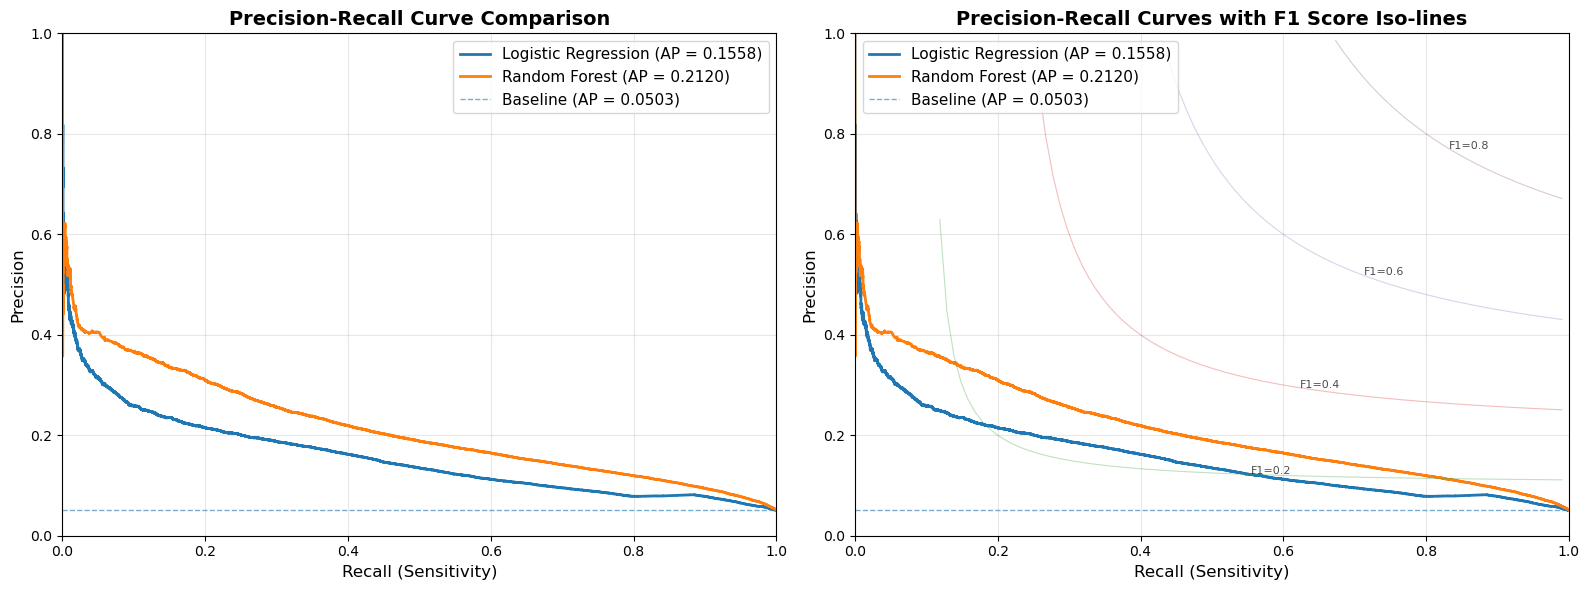

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


# ============================================================
# Precision-Recall Curves for Imbalanced Classification
# ============================================================

model_scores = {
    "Logistic Regression": y_pred_proba,
    "Random Forest": y_pred_rf_proba
}

baseline_precision = np.mean(y_val)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pr_results = {}

for model_name, scores in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_val, scores)
    average_precision = average_precision_score(y_val, scores)

    pr_results[model_name] = {
        "precision": precision,
        "recall": recall,
        "average_precision": average_precision
    }

    label = f"{model_name} (AP = {average_precision:.4f})"

    axes[0].plot(
        recall,
        precision,
        linewidth=2,
        label=label
    )

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=label
    )


# Baseline line
for ax in axes:
    ax.axhline(
        y=baseline_precision,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label=f"Baseline (AP = {baseline_precision:.4f})"
    )

    ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=11)


axes[0].set_title(
    "Precision-Recall Curve Comparison",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_title(
    "Precision-Recall Curves with F1 Score Iso-lines",
    fontsize=14,
    fontweight="bold"
)


# Add F1-score iso-lines
f1_scores = [0.2, 0.4, 0.6, 0.8]
recall_range = np.linspace(0.01, 0.99, 100)

for f1 in f1_scores:
    denominator = 2 * recall_range - f1
    precision_f1 = f1 * recall_range / denominator

    valid = (denominator > 0) & (precision_f1 >= 0) & (precision_f1 <= 1)

    axes[1].plot(
        recall_range[valid],
        precision_f1[valid],
        alpha=0.3,
        linewidth=0.8
    )

    if np.any(valid):
        mid_idx = len(recall_range[valid]) // 2
        axes[1].text(
            recall_range[valid][mid_idx],
            precision_f1[valid][mid_idx],
            f"F1={f1:.1f}",
            fontsize=8,
            alpha=0.7
        )


plt.tight_layout()
plt.show()

# Threshold Adjustment for Imbalanced Classification


In [21]:

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)



model_scores = {
    "Logistic Regression": y_pred_proba,
    "Random Forest": y_pred_rf_proba
}


def evaluate_at_threshold(y_true, scores, threshold):
    """
    Evaluate classification performance at a given probability threshold.
    """
    y_pred = (scores >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }


def find_best_f1_threshold(y_true, scores):
    """
    Find the threshold that maximizes F1 score.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # precision and recall have one more element than thresholds
    precision = precision[:-1]
    recall = recall[:-1]

    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

    best_idx = np.argmax(f1_scores)

    return {
        "Threshold": thresholds[best_idx],
        "Precision": precision[best_idx],
        "Recall": recall[best_idx],
        "F1 Score": f1_scores[best_idx]
    }


def find_threshold_for_target_recall(y_true, scores, target_recall=0.85):
    """
    Find the threshold that achieves at least the target recall
    while keeping precision as high as possible.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    precision = precision[:-1]
    recall = recall[:-1]

    candidate_indices = np.where(recall >= target_recall)[0]

    if len(candidate_indices) == 0:
        return None

    # Among thresholds that meet the recall target, choose the one with highest precision
    best_idx = candidate_indices[np.argmax(precision[candidate_indices])]

    f1 = 2 * precision[best_idx] * recall[best_idx] / (
        precision[best_idx] + recall[best_idx] + 1e-10
    )

    return {
        "Threshold": thresholds[best_idx],
        "Precision": precision[best_idx],
        "Recall": recall[best_idx],
        "F1 Score": f1
    }


results = []

target_recall = 0.85

for model_name, scores in model_scores.items():

    # Default threshold = 0.5
    default_result = evaluate_at_threshold(
        y_true=y_val,
        scores=scores,
        threshold=0.5
    )
    default_result["Model"] = model_name
    default_result["Method"] = "Default Threshold"

    # Best F1 threshold
    best_f1_result = find_best_f1_threshold(
        y_true=y_val,
        scores=scores
    )
    best_f1_result["Model"] = model_name
    best_f1_result["Method"] = "Best F1 Threshold"

    # Target recall threshold
    target_recall_result = find_threshold_for_target_recall(
        y_true=y_val,
        scores=scores,
        target_recall=target_recall
    )

    if target_recall_result is not None:
        target_recall_result["Model"] = model_name
        target_recall_result["Method"] = f"Target Recall >= {target_recall}"
        results.append(target_recall_result)

    results.append(default_result)
    results.append(best_f1_result)


threshold_results = pd.DataFrame(results)

threshold_results = threshold_results[
    ["Model", "Method", "Threshold", "Precision", "Recall", "F1 Score"]
]

threshold_results

,Model,Method,Threshold,Precision,Recall,F1 Score
0,Logistic Regression,Target Recall >= 0.85,0.408532,0.081621,0.883670,0.149439
1,Logistic Regression,Default Threshold,0.500000,0.096650,0.691745,0.169603
2,Logistic Regression,Best F1 Threshold,0.639864,0.176870,0.347394,0.234399
3,Random Forest,Target Recall >= 0.85,0.410588,0.107706,0.850040,0.191187
4,Random Forest,Default Threshold,0.500000,0.124132,0.779010,0.214142
5,Random Forest,Best F1 Threshold,0.749740,0.231782,0.368631,0.284611


# Method 2: Adding Interaction Features

In [22]:


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score



df_features_enhanced = df_features.copy()


# Original features used in the baseline Random Forest model
original_feature_cols = [
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "age_normalized",
    "is_active_member"
]


# Create additional behavior-based features
df_features_enhanced["purchase_intensity"] = (
    df_features_enhanced["total_purchases"] /
    (df_features_enhanced["days_since_last_purchase"] + 1)
)

df_features_enhanced["avg_spend_per_purchase"] = (
    df_features_enhanced["total_spent"] /
    (df_features_enhanced["total_purchases"] + 1)
)

df_features_enhanced["spending_power"] = (
    df_features_enhanced["total_spent"] *
    df_features_enhanced["purchase_recency_score"]
)

df_features_enhanced["loyalty_score"] = (
    df_features_enhanced["total_purchases"] *
    df_features_enhanced["is_active_member"]
)


# Enhanced feature set
enhanced_feature_cols = [
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "age_normalized",
    "is_active_member",
    "purchase_recency_score",
    "purchase_intensity",
    "avg_spend_per_purchase",
    "spending_power",
    "loyalty_score"
]


X_enhanced = df_features_enhanced[enhanced_feature_cols]


# Use the same split setting as the original model
X_train_enh, X_val_enh, y_train_enh, y_val_enh = train_test_split(
    X_enhanced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train enhanced Random Forest model
rf_enhanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_enhanced.fit(X_train_enh, y_train_enh)


# Predict with default threshold = 0.5
y_pred_enh_proba = rf_enhanced.predict_proba(X_val_enh)[:, 1]
y_pred_enh = (y_pred_enh_proba >= 0.5).astype(int)


# Evaluate enhanced model
enh_precision = precision_score(y_val_enh, y_pred_enh, zero_division=0)
enh_recall = recall_score(y_val_enh, y_pred_enh, zero_division=0)
enh_f1 = f1_score(y_val_enh, y_pred_enh, zero_division=0)
enh_auc = roc_auc_score(y_val_enh, y_pred_enh_proba)


# Compare original and enhanced Random Forest models
feature_engineering_results = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Enhanced Random Forest"
    ],
    "Number of Features": [
        len(original_feature_cols),
        len(enhanced_feature_cols)
    ],
    "Precision": [
        rf_precision,
        enh_precision
    ],
    "Recall": [
        rf_recall,
        enh_recall
    ],
    "F1 Score": [
        rf_f1,
        enh_f1
    ],
    "AUC-ROC": [
        rf_auc,
        enh_auc
    ]
})


# Calculate changes relative to the original Random Forest model
for metric in ["Precision", "Recall", "F1 Score", "AUC-ROC"]:
    feature_engineering_results[f"{metric} Change"] = (
        feature_engineering_results[metric] -
        feature_engineering_results.loc[0, metric]
    )


feature_engineering_results

,Model,Number of Features,Precision,Recall,F1 Score,AUC-ROC,Precision Change,Recall Change,F1 Score Change,AUC-ROC Change
0,Original Random Forest,6,0.124132,0.779010,0.214142,0.819188,0.000000,0.000000,0.000000,0.000000
1,Enhanced Random Forest,11,0.135735,0.713561,0.228084,0.814947,0.011603,-0.065449,0.013942,-0.004241


# Sum of ROC Curve Visulisation


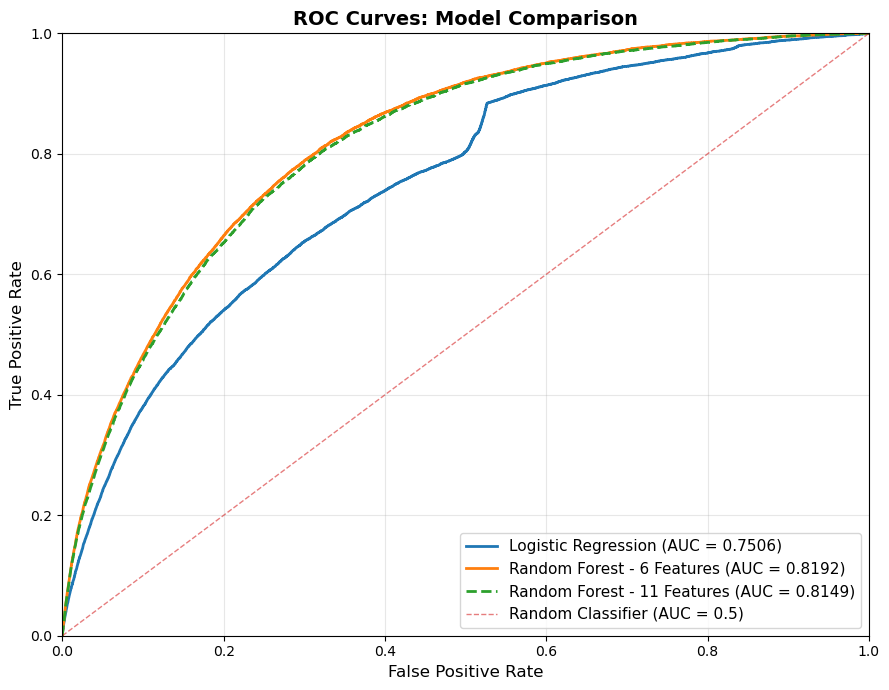

,Model,AUC-ROC
0,Logistic Regression,0.750625
1,Random Forest - 6 Features,0.819188
2,Random Forest - 11 Features,0.814947


In [23]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc



# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_rf_proba)
fpr_enh, tpr_enh, _ = roc_curve(y_val_enh, y_pred_enh_proba)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_enh = auc(fpr_enh, tpr_enh)


# Plot ROC curves
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest - 6 Features (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    fpr_enh,
    tpr_enh,
    linewidth=2,
    linestyle="--",
    label=f"Random Forest - 11 Features (AUC = {roc_auc_enh:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="Random Classifier (AUC = 0.5)"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves: Model Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


roc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest - 6 Features",
        "Random Forest - 11 Features"
    ],
    "AUC-ROC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_enh
    ]
})

roc_results


# Confusion Matrix Visualization

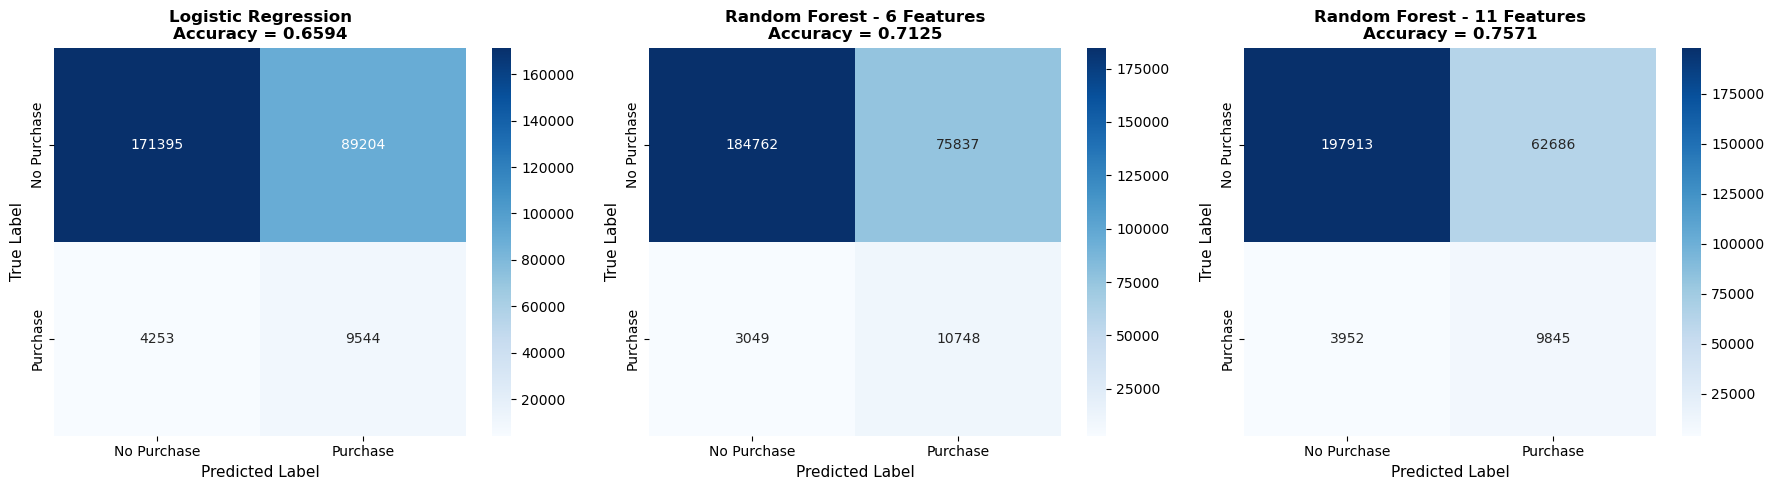

,Model,TN,FP,FN,TP,Accuracy,False Positive Rate,False Negative Rate
0,Logistic Regression,171395,89204,4253,9544,0.659408,0.342304,0.308255
1,Random Forest - 6 Features,184762,75837,3049,10748,0.712510,0.291010,0.220990
2,Random Forest - 11 Features,197913,62686,3952,9845,0.757147,0.240546,0.286439


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score

models = {
    "Logistic Regression": {
        "y_true": y_val,
        "y_pred": y_pred,
        "accuracy": lr_accuracy
    },
    "Random Forest - 6 Features": {
        "y_true": y_val,
        "y_pred": y_pred_rf,
        "accuracy": rf_accuracy
    },
    "Random Forest - 11 Features": {
        "y_true": y_val_enh,
        "y_pred": y_pred_enh,
        "accuracy": accuracy_score(y_val_enh, y_pred_enh)
    }
}


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

confusion_summary = []

for ax, (model_name, model_data) in zip(axes, models.items()):
    cm = confusion_matrix(
        model_data["y_true"],
        model_data["y_pred"]
    )

    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"]
    )

    ax.set_title(
        f"{model_name}\nAccuracy = {model_data['accuracy']:.4f}",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

    confusion_summary.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": model_data["accuracy"],
        "False Positive Rate": fp / (fp + tn),
        "False Negative Rate": fn / (fn + tp)
    })


plt.tight_layout()
plt.show()


confusion_summary = pd.DataFrame(confusion_summary)
confusion_summary

# K - Fold Validation

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}


# Logistic Regression pipeline
# Scaling is applied inside each CV fold to avoid data leakage.
lr_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        solver="lbfgs"
    ))
])


# Random Forest model
# A smaller forest is used here to speed up cross-validation.
rf_cv_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# Use original, unscaled training data for cross-validation
X_cv = X_train
y_cv = y_train


lr_cv_results = cross_validate(
    lr_cv_model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


rf_cv_results = cross_validate(
    rf_cv_model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)


def summarize_cv_results(model_name, cv_results):
    """
    Convert cross-validation results into a clean summary table.
    """
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    summary = []

    for metric in metrics:
        scores = cv_results[f"test_{metric}"]

        summary.append({
            "Model": model_name,
            "Metric": metric,
            "Fold 1": scores[0],
            "Fold 2": scores[1],
            "Fold 3": scores[2],
            "Mean": scores.mean(),
            "Std": scores.std()
        })

    return pd.DataFrame(summary)


lr_cv_summary = summarize_cv_results(
    "Logistic Regression",
    lr_cv_results
)

rf_cv_summary = summarize_cv_results(
    "Random Forest - 6 Features",
    rf_cv_results
)


cv_summary = pd.concat(
    [lr_cv_summary, rf_cv_summary],
    ignore_index=True
)


cv_summary

,Model,Metric,Fold 1,Fold 2,Fold 3,Mean,Std
0,Logistic Regression,accuracy,0.661307,0.659226,0.660130,0.660221,0.000852
1,Logistic Regression,precision,0.096698,0.096782,0.097192,0.096891,0.000216
2,Logistic Regression,recall,0.687649,0.693395,0.694825,0.691956,0.003101
3,Logistic Regression,f1,0.169554,0.169856,0.170530,0.169980,0.000408
4,Logistic Regression,roc_auc,0.749281,0.748976,0.751707,0.749988,0.001222
5,Random Forest - 6 Features,accuracy,0.713438,0.714315,0.720377,0.716044,0.003085
6,Random Forest - 6 Features,precision,0.123303,0.123351,0.125799,0.124151,0.001166
7,Random Forest - 6 Features,recall,0.769080,0.766676,0.766688,0.767481,0.001131
8,Random Forest - 6 Features,f1,0.212531,0.212511,0.216135,0.213726,0.001704
9,Random Forest - 6 Features,roc_auc,0.817343,0.814663,0.817803,0.816603,0.001384


---

# Upgrade: Top-5 SKU Recommendation (Memory-Optimized)

This section converts the user-level prediction model to an item-level recommendation system that generates a ranked Top-5 list of specific articles (SKUs) per customer for the next 7 days.

**MODIFIED:** Changed from Top-12 to Top-5 for memory efficiency.

**Key Requirements:**
- Use cutoff date T (already computed in notebook)
- Target window: (T, T+7 days]
- Build candidate sets (100-500 articles per customer) using ONLY data ≤ T
- Create (customer_id, article_id) pairs with labels from target window
- Features computed ONLY from transactions ≤ T (no future leakage)
- Handle class imbalance with negative sampling
- Train ranker on (customer, article) pairs
- Output in Kaggle submission format



### Step 1: Build Candidate Sets Per Customer

Build candidate articles for each customer using ONLY data up to cutoff date T:
- Global popular items from recent history (last 4-8 weeks before T)
- Customer's recent purchases before T
- Backfill with popular items if customer has too few candidates


In [41]:
from datetime import timedelta
import time
import gc

import numpy as np
import pandas as pd


# ============================================================
# Step 1: Build Candidate Sets per Customer
# ============================================================

required_config_vars = {
    "ACTIVE_WEEKS": "Active customer filter window in weeks",
    "CAND_PER_USER": "Maximum number of candidates per customer",
    "CHUNK_SIZE": "Chunk size for CSV reading",
    "SEED": "Random seed",
    "cutoff_date": "Cutoff date for training"
}

missing_vars = []

for var_name, description in required_config_vars.items():
    if var_name not in globals():
        missing_vars.append(f"{var_name} ({description})")

if missing_vars:
    raise NameError(
        "Missing required configuration variables. "
        "Please run the global configuration cell first.\n"
        "Missing variables:\n  " + "\n  ".join(missing_vars)
    )


transactions_path = DATA_DIR / "transactions_train.csv"

print("=" * 80)
print("Step 1: Building Candidate Sets per Customer")
print("=" * 80)
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Active customer window: last {ACTIVE_WEEKS} weeks before cutoff")
print(f"Max candidates per customer: {CAND_PER_USER}")
print("Using transactions before cutoff date only to avoid future leakage.")

start_time = time.time()


# ============================================================
# 1. Identify active customers before cutoff date
# ============================================================

print(f"\n1. Identifying active customers from the last {ACTIVE_WEEKS} weeks...")

active_window_start = cutoff_date - timedelta(days=ACTIVE_WEEKS * 7)
active_customers = set()
chunk_count = 0

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "t_dat"],
    chunksize=CHUNK_SIZE,
    dtype={"customer_id": "string"}
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    active_chunk = chunk[
        (chunk["t_dat"] >= active_window_start) &
        (chunk["t_dat"] < cutoff_date)
    ]

    if not active_chunk.empty:
        active_customers.update(active_chunk["customer_id"].unique())

    chunk_count += 1

    if chunk_count % 20 == 0:
        print(f"  Processed {chunk_count} chunks...")

print(f"  Active customers found: {len(active_customers):,}")


# ============================================================
# 2. Compute globally popular items before cutoff date
# ============================================================

print("\n2. Computing globally popular items from the last 8 weeks...")

popular_window_start = cutoff_date - timedelta(days=56)
item_counts = {}
chunk_count = 0

for chunk in pd.read_csv(
    transactions_path,
    usecols=["article_id", "t_dat"],
    chunksize=CHUNK_SIZE,
    dtype={"article_id": "int32"}
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    recent_chunk = chunk[
        (chunk["t_dat"] >= popular_window_start) &
        (chunk["t_dat"] < cutoff_date)
    ]

    if not recent_chunk.empty:
        chunk_counts = recent_chunk["article_id"].value_counts()

        for article_id, count in chunk_counts.items():
            item_counts[article_id] = item_counts.get(article_id, 0) + count

    chunk_count += 1

    if chunk_count % 20 == 0:
        print(f"  Processed {chunk_count} chunks...")


# Keep item popularity for later feature engineering
item_popularity = item_counts.copy()

popular_items = sorted(
    item_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:200]

popular_items_list = [article_id for article_id, _ in popular_items]

print(f"  Popular items identified: {len(popular_items_list):,}")

del item_counts
gc.collect()


# ============================================================
# 3. Compute each active customer's recent purchases
# ============================================================

print("\n3. Computing recent purchases for active customers...")

recent_purchase_start = cutoff_date - timedelta(days=30)
user_recent_items = {}
chunk_count = 0

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "article_id", "t_dat"],
    chunksize=CHUNK_SIZE,
    dtype={"customer_id": "string", "article_id": "int32"}
):
    chunk["t_dat"] = pd.to_datetime(chunk["t_dat"])

    recent_chunk = chunk[
        (chunk["t_dat"] >= recent_purchase_start) &
        (chunk["t_dat"] < cutoff_date) &
        (chunk["customer_id"].isin(active_customers))
    ]

    if not recent_chunk.empty:
        for customer_id, group in recent_chunk.groupby("customer_id"):
            if customer_id not in user_recent_items:
                user_recent_items[customer_id] = set()

            user_recent_items[customer_id].update(group["article_id"].unique())

    chunk_count += 1

    if chunk_count % 20 == 0:
        print(f"  Processed {chunk_count} chunks...")

print(f"  Customers with recent purchases: {len(user_recent_items):,}")


# ============================================================
# 4. Build candidate sets
# ============================================================

print(f"\n4. Building candidate sets with up to {CAND_PER_USER} items per customer...")

candidate_sets = {}

all_customers = df_features["customer_id"].astype("string").unique()
active_customers_in_features = [
    customer_id for customer_id in all_customers
    if customer_id in active_customers
]

print(
    f"  Processing {len(active_customers_in_features):,} active customers "
    f"out of {len(all_customers):,} total customers"
)


def add_unique_items(candidate_list, new_items, max_size):
    """
    Add unique items to a candidate list while preserving order.
    """
    existing_items = set(candidate_list)

    for item in new_items:
        if item not in existing_items:
            candidate_list.append(item)
            existing_items.add(item)

        if len(candidate_list) >= max_size:
            break

    return candidate_list


recent_quota = min(100, CAND_PER_USER)

for customer_id in active_customers_in_features:
    candidates = []

    # Add customer-specific recent items first
    if customer_id in user_recent_items:
        recent_items = list(user_recent_items[customer_id])[:recent_quota]
        candidates = add_unique_items(
            candidate_list=candidates,
            new_items=recent_items,
            max_size=CAND_PER_USER
        )

    # Backfill with globally popular items
    candidates = add_unique_items(
        candidate_list=candidates,
        new_items=popular_items_list,
        max_size=CAND_PER_USER
    )

    candidate_sets[customer_id] = candidates


candidate_lengths = [len(items) for items in candidate_sets.values()]

print(f"  Candidate sets built for {len(candidate_sets):,} customers")
print(f"  Average candidates per customer: {np.mean(candidate_lengths):.0f}")
print(f"  Minimum candidates per customer: {np.min(candidate_lengths):.0f}")
print(f"  Maximum candidates per customer: {np.max(candidate_lengths):.0f}")
print(f"  Runtime: {time.time() - start_time:.2f} seconds")


# Clean up memory
del active_customers
gc.collect()

print("  Memory cleaned up. Kept user_recent_items and item_popularity for later steps.")

Step 1: Building Candidate Sets per Customer
Cutoff date: 2020-09-15
Active customer window: last 8 weeks before cutoff
Max candidates per customer: 150
Using transactions before cutoff date only to avoid future leakage.

1. Identifying active customers from the last 8 weeks...
  Processed 20 chunks...
  Processed 40 chunks...
  Processed 60 chunks...
  Active customers found: 385,133

2. Computing globally popular items from the last 8 weeks...
  Processed 20 chunks...
  Processed 40 chunks...
  Processed 60 chunks...
  Popular items identified: 200

3. Computing recent purchases for active customers...
  Processed 20 chunks...
  Processed 40 chunks...
  Processed 60 chunks...
  Customers with recent purchases: 245,554

4. Building candidate sets with up to 150 items per customer...
  Processing 385,133 active customers out of 1,371,980 total customers
  Candidate sets built for 385,133 customers
  Average candidates per customer: 150
  Minimum candidates per customer: 150
  Maximum c

### Step 2: Create (Customer, Article) Pairs with Labels

## Optimization: Memory-safe labeling for (customer, article) pairs

Create (customer_id, article_id) pairs from candidates and label them:
- y = 1 if customer purchased that article in target window (T, T+7 days]
- y = 0 otherwise
- Labels come ONLY from target window (no leakage)

**Optimizations:**
- Vectorized operations instead of iterrows()
- DataFrame merge instead of Python set lookups
- Efficient dtypes (int32, int8) to reduce memory
- Optional negative sampling to control dataset size


In [ ]:
from datetime import timedelta
import time
import gc

import numpy as np
import pandas as pd


# ============================================================
# Step 2: Create (Customer, Article) Pairs with Labels
# ============================================================

required_config_vars = {
    "candidate_sets": "Candidate sets generated in Step 1",
    "NEG_PER_USER": "Maximum number of negative samples per customer",
    "CHUNK_SIZE": "Chunk size for CSV reading",
    "SEED": "Random seed",
    "cutoff_date": "Cutoff date for training"
}

missing_vars = []

for var_name, description in required_config_vars.items():
    if var_name not in globals():
        missing_vars.append(f"{var_name} ({description})")

if missing_vars:
    raise NameError(
        "Missing required variables. Please run the previous configuration "
        "and candidate generation cells first.\n"
        "Missing variables:\n  " + "\n  ".join(missing_vars)
    )


transactions_path = DATA_DIR / "transactions_train.csv"

print("=" * 80)
print("Step 2: Creating (Customer, Article) Pairs with Labels")
print("=" * 80)

start_time = time.time()


# ============================================================
# 1. Define target window
# ============================================================

# Convention:
# cutoff_date is the last day used for historical features.
# The target window is the following 7 days.
target_start = cutoff_date + timedelta(days=1)
target_end = cutoff_date + timedelta(days=7)

target_start_str = target_start.strftime("%Y-%m-%d")
target_end_str = target_end.strftime("%Y-%m-%d")

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Target window: {target_start.date()} to {target_end.date()}")


# ============================================================
# 2. Load actual purchases in target window
# ============================================================

print("\n1. Loading actual purchases in target window...")

actual_chunks = []
chunk_count = 0

for chunk in pd.read_csv(
    transactions_path,
    usecols=["customer_id", "article_id", "t_dat"],
    chunksize=CHUNK_SIZE,
    dtype={"customer_id": "string", "article_id": "int32"}
):
    # t_dat is stored as YYYY-MM-DD, so string comparison is valid and faster
    target_chunk = chunk[
        (chunk["t_dat"] >= target_start_str) &
        (chunk["t_dat"] <= target_end_str)
    ]

    if not target_chunk.empty:
        actual_chunks.append(target_chunk[["customer_id", "article_id"]])

    chunk_count += 1

    if chunk_count % 10 == 0:
        print(f"  Processed {chunk_count} chunks...")


if actual_chunks:
    actual_df = (
        pd.concat(actual_chunks, ignore_index=True)
        .drop_duplicates()
        .astype({"customer_id": "string", "article_id": "int32"})
    )
else:
    actual_df = pd.DataFrame({
        "customer_id": pd.Series(dtype="string"),
        "article_id": pd.Series(dtype="int32")
    })


actual_labeled = actual_df.copy()
actual_labeled["label"] = np.int8(1)

print(
    f"  Found {len(actual_df):,} unique customer-article purchases "
    f"in the target window"
)

del actual_chunks
gc.collect()


# ============================================================
# 3. Create candidate pairs and labels in batches
# ============================================================

print("\n2. Creating and labeling candidate pairs in batches...")

CUSTOMER_BATCH_SIZE = 20_000
base_cols = ["customer_id", "article_id", "label"]

customer_ids = list(candidate_sets.keys())
labeled_chunks = []

total_candidate_pairs = 0
total_positive_pairs = 0

for batch_start in range(0, len(customer_ids), CUSTOMER_BATCH_SIZE):
    batch_customers = customer_ids[
        batch_start: batch_start + CUSTOMER_BATCH_SIZE
    ]

    candidate_rows = []

    for customer_id in batch_customers:
        # dict.fromkeys removes duplicates while preserving order
        unique_candidates = list(dict.fromkeys(candidate_sets[customer_id]))

        for article_id in unique_candidates:
            candidate_rows.append((customer_id, article_id))

    if not candidate_rows:
        continue

    cand_chunk = pd.DataFrame(
        candidate_rows,
        columns=["customer_id", "article_id"]
    )

    cand_chunk = cand_chunk.astype({
        "customer_id": "string",
        "article_id": "int32"
    })

    cand_chunk = cand_chunk.drop_duplicates(
        subset=["customer_id", "article_id"]
    )

    total_candidate_pairs += len(cand_chunk)

    # Label pairs by matching actual purchases in target window
    labeled_chunk = cand_chunk.merge(
        actual_labeled,
        on=["customer_id", "article_id"],
        how="left"
    )

    labeled_chunk["label"] = (
        labeled_chunk["label"]
        .fillna(0)
        .astype("int8")
    )

    # Negative sampling per customer
    if NEG_PER_USER is not None:
        positives = labeled_chunk[labeled_chunk["label"] == 1]
        negatives = labeled_chunk[labeled_chunk["label"] == 0]

        if not negatives.empty:
            negatives_sampled = (
                negatives
                .sample(frac=1, random_state=SEED + batch_start)
                .groupby("customer_id", sort=False, group_keys=False)
                .head(NEG_PER_USER)
            )

            labeled_chunk = pd.concat(
                [positives, negatives_sampled],
                ignore_index=True
            )

        del positives, negatives
        gc.collect()

    total_positive_pairs += labeled_chunk["label"].sum()

    labeled_chunks.append(labeled_chunk[base_cols])

    if (batch_start // CUSTOMER_BATCH_SIZE + 1) % 5 == 0:
        print(
            f"  Processed {batch_start + len(batch_customers):,} "
            f"customers..."
        )

    del candidate_rows, cand_chunk, labeled_chunk
    gc.collect()


# ============================================================
# 4. Combine labeled chunks
# ============================================================

print("\n3. Combining labeled pairs...")

if labeled_chunks:
    df_pairs = pd.concat(labeled_chunks, ignore_index=True)
else:
    df_pairs = pd.DataFrame({
        "customer_id": pd.Series(dtype="string"),
        "article_id": pd.Series(dtype="int32"),
        "label": pd.Series(dtype="int8")
    })


# Final shuffle
df_pairs = (
    df_pairs
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)


# ============================================================
# 5. Enforce clean output schema
# ============================================================

df_pairs = df_pairs[base_cols].copy()

df_pairs["customer_id"] = df_pairs["customer_id"].astype("string")
df_pairs["article_id"] = df_pairs["article_id"].astype("int32")
df_pairs["label"] = df_pairs["label"].astype("int8")

assert list(df_pairs.columns) == base_cols
assert df_pairs["label"].isin([0, 1]).all()

if NEG_PER_USER is not None and not df_pairs.empty:
    max_negs = (
        df_pairs[df_pairs["label"] == 0]
        .groupby("customer_id")
        .size()
        .max()
    )

    assert max_negs <= NEG_PER_USER, (
        f"Negative cap violated: max {max_negs} > {NEG_PER_USER}"
    )


# ============================================================
# 6. Candidate coverage check
# ============================================================

candidate_customer_set = set(candidate_sets.keys())

actual_for_candidate_customers = actual_df[
    actual_df["customer_id"].isin(candidate_customer_set)
]

candidate_positive_pairs = df_pairs["label"].sum()

candidate_recall = (
    candidate_positive_pairs / len(actual_for_candidate_customers)
    if len(actual_for_candidate_customers) > 0
    else 0
)


print("\nStep 2 Summary:")
print(f"  Raw candidate pairs before sampling: {total_candidate_pairs:,}")
print(f"  Final training pairs: {len(df_pairs):,}")
print(f"  Positive pairs: {df_pairs['label'].sum():,}")
print(f"  Negative pairs: {(df_pairs['label'] == 0).sum():,}")
print(f"  Positive rate: {df_pairs['label'].mean() * 100:.2f}%")
print(f"  Candidate recall: {candidate_recall:.4f}")
print(f"  Runtime: {time.time() - start_time:.2f} seconds")

print("\nSchema:")
print(df_pairs.dtypes)

print("\nStep 2 complete. df_pairs is ready for Step 3 feature engineering.")

Step 2: Creating (Customer, Article) Pairs with Labels
Cutoff date: 2020-09-15
Target window: 2020-09-16 to 2020-09-22

1. Loading actual purchases in target window...
  Processed 10 chunks...
  Processed 20 chunks...
  Processed 30 chunks...
  Processed 40 chunks...
  Processed 50 chunks...
  Processed 60 chunks...
  Found 213,728 unique customer-article purchases in the target window

2. Creating and labeling candidate pairs in batches...
  Processed 100,000 customers...
  Processed 200,000 customers...
  Processed 300,000 customers...
  Processed 385,133 customers...

3. Combining labeled pairs...

Step 2 Summary:
  Raw candidate pairs before sampling: 57,769,950
  Final training pairs: 11,569,291
  Positive pairs: 15,301
  Negative pairs: 11,553,990
  Positive rate: 0.13%
  Candidate recall: 0.1170
  Runtime: 112.48 seconds

Schema:
customer_id    string[python]
article_id              int32
label                    int8
dtype: object

Step 2 complete. df_pairs is ready for Step 3 

In [28]:
import pandas as pd


# ============================================================
# Integrity Check: df_pairs
# ============================================================

def check_df_pairs_integrity(df_pairs):
    """
    Check whether df_pairs has the expected schema and valid labels.
    
    Expected columns:
    - customer_id
    - article_id
    - label
    
    Each row represents one customer-article candidate pair.
    label = 1 means the customer purchased the article in the target window.
    label = 0 means the customer did not purchase the article in the target window.
    """

    required_cols = ["customer_id", "article_id", "label"]

    print("=" * 80)
    print("Integrity Check: df_pairs")
    print("=" * 80)

    print(f"\nDataFrame shape: {df_pairs.shape}")
    print(f"Rows: {len(df_pairs):,}")
    print(f"Columns: {df_pairs.shape[1]}")

    # Check required columns
    missing_cols = [col for col in required_cols if col not in df_pairs.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    print(f"\nRequired columns present: {required_cols}")

    # Keep only required columns for this check
    extra_cols = [col for col in df_pairs.columns if col not in required_cols]

    if extra_cols:
        print(f"\nWarning: extra columns found: {extra_cols}")
        print("These columns are not required for the base df_pairs schema.")

    # Check missing values
    missing_summary = df_pairs[required_cols].isnull().sum()

    if missing_summary.sum() > 0:
        raise ValueError(
            "Missing values found in required columns:\n"
            f"{missing_summary[missing_summary > 0]}"
        )

    print("\nNo missing values in required columns.")

    # Check label values
    invalid_labels = df_pairs[~df_pairs["label"].isin([0, 1])]

    if len(invalid_labels) > 0:
        raise ValueError(
            f"Invalid label values found. Labels must be 0 or 1. "
            f"Invalid rows: {len(invalid_labels):,}"
        )

    print("Labels are valid: only 0 and 1.")

    # Check duplicates
    duplicate_count = df_pairs.duplicated(
        subset=["customer_id", "article_id"]
    ).sum()

    if duplicate_count > 0:
        raise ValueError(
            f"Duplicate customer-article pairs found: {duplicate_count:,}"
        )

    print("No duplicate customer-article pairs.")

    # Enforce recommended dtypes
    df_pairs["customer_id"] = df_pairs["customer_id"].astype("string")
    df_pairs["article_id"] = df_pairs["article_id"].astype("int32")
    df_pairs["label"] = df_pairs["label"].astype("int8")

    # Label distribution
    positive_count = int(df_pairs["label"].sum())
    negative_count = int((df_pairs["label"] == 0).sum())
    positive_rate = df_pairs["label"].mean()

    summary = pd.DataFrame({
        "Metric": [
            "Total pairs",
            "Positive pairs",
            "Negative pairs",
            "Positive rate",
            "Unique customers",
            "Unique articles"
        ],
        "Value": [
            len(df_pairs),
            positive_count,
            negative_count,
            f"{positive_rate * 100:.2f}%",
            df_pairs["customer_id"].nunique(),
            df_pairs["article_id"].nunique()
        ]
    })

    print("\nLabel distribution:")
    print(f"Positive pairs: {positive_count:,} ({positive_rate * 100:.2f}%)")
    print(f"Negative pairs: {negative_count:,} ({(1 - positive_rate) * 100:.2f}%)")

    print("\nColumn dtypes:")
    print(df_pairs[required_cols].dtypes)

    print("\nIntegrity check passed. df_pairs is ready for feature engineering.")

    return df_pairs, summary


df_pairs, df_pairs_summary = check_df_pairs_integrity(df_pairs)

df_pairs_summary

Integrity Check: df_pairs

DataFrame shape: (11569291, 3)
Rows: 11,569,291
Columns: 3

Required columns present: ['customer_id', 'article_id', 'label']

No missing values in required columns.
Labels are valid: only 0 and 1.
No duplicate customer-article pairs.

Label distribution:
Positive pairs: 15,301 (0.13%)
Negative pairs: 11,553,990 (99.87%)

Column dtypes:
customer_id    string[python]
article_id              int32
label                    int8
dtype: object

Integrity check passed. df_pairs is ready for feature engineering.


,Metric,Value
0,Total pairs,11569291
1,Positive pairs,15301
2,Negative pairs,11553990
3,Positive rate,0.13%
4,Unique customers,385133
5,Unique articles,19677


### Step 3: Add Customer and Item Features

This step enriches candidate customer-article pairs with customer-level and item-level features.

Historical interaction features are not added here because the full transaction history is not kept in memory in this notebook. This avoids creating incomplete or misleading interaction features from partial transaction chunks.

In [34]:
print("="*80)
print("Step 3: Add Customer and Item Features")
print("="*80)

# ---------------------------------------------------------------------
# 0. Basic checks
# ---------------------------------------------------------------------
required_cols = ["customer_id", "article_id", "label"]
missing_cols = [col for col in required_cols if col not in df_pairs.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in df_pairs: {missing_cols}")

df_pairs = df_pairs.copy()

df_pairs["customer_id"] = df_pairs["customer_id"].astype(str)
df_pairs["article_id"] = pd.to_numeric(df_pairs["article_id"], errors="raise").astype("int64")

print(f"Starting df_pairs shape: {df_pairs.shape}")


# ---------------------------------------------------------------------
# 1. Standardize dataframe names
# ---------------------------------------------------------------------
if "articles" not in globals() and "df_articles" in globals():
    articles = df_articles
    print("✓ Using df_articles as articles")

if "df_features" not in globals() and "customer_features_train" in globals():
    df_features = customer_features_train
    print("✓ Using customer_features_train as df_features")


# ---------------------------------------------------------------------
# 2. Add customer-level features
# ---------------------------------------------------------------------
if "df_features" in globals():
    customer_features = df_features.copy()
    customer_features["customer_id"] = customer_features["customer_id"].astype(str)

    # Use only model-friendly customer features
    selected_customer_cols = [
        "customer_id",
        "total_purchases",
        "avg_price",
        "total_spent",
        "days_since_last_purchase",
        "purchase_recency_score",
        "age_normalized",
        "is_active_member",
        "purchase_intensity",
        "avg_spend_per_purchase",
        "spending_power",
        "loyalty_score"
    ]

    selected_customer_cols = [
        col for col in selected_customer_cols
        if col in customer_features.columns
    ]

    customer_cols_to_add = [
        col for col in selected_customer_cols
        if col == "customer_id" or col not in df_pairs.columns
    ]

    if len(customer_cols_to_add) > 1:
        df_pairs = df_pairs.merge(
            customer_features[customer_cols_to_add],
            on="customer_id",
            how="left"
        )
        print(f"✓ Added customer-level features: {len(customer_cols_to_add) - 1}")
    else:
        print("✓ Customer-level features already exist in df_pairs. Skipped merge.")
else:
    print("⚠️ No customer feature dataframe found. Skipped customer-level feature merge.")


# ---------------------------------------------------------------------
# 3. Add item-level features from articles
# ---------------------------------------------------------------------
if "articles" in globals():
    article_features = articles.copy()

    article_features["article_id"] = pd.to_numeric(
        article_features["article_id"], errors="raise"
    ).astype("int64")

    selected_article_cols = [
        "article_id",
        "product_code",
        "product_type_no",
        "graphical_appearance_no",
        "colour_group_code",
        "perceived_colour_value_id",
        "perceived_colour_master_id",
        "department_no",
        "index_group_no",
        "section_no",
        "garment_group_no"
    ]

    selected_article_cols = [
        col for col in selected_article_cols
        if col in article_features.columns
    ]

    # Add a simple text-length feature if product descriptions are available
    if "detail_desc" in article_features.columns:
        article_features["detail_desc_len"] = (
            article_features["detail_desc"]
            .fillna("")
            .astype(str)
            .str.len()
            .astype("int32")
        )
        selected_article_cols.append("detail_desc_len")

    article_cols_to_add = [
        col for col in selected_article_cols
        if col == "article_id" or col not in df_pairs.columns
    ]

    if len(article_cols_to_add) > 1:
        df_pairs = df_pairs.merge(
            article_features[article_cols_to_add],
            on="article_id",
            how="left"
        )
        print(f"✓ Added item-level features: {len(article_cols_to_add) - 1}")
    else:
        print("✓ Item-level features already exist in df_pairs. Skipped merge.")
else:
    print("⚠️ No article dataframe found. Skipped item-level feature merge.")


# ---------------------------------------------------------------------
# 4. Handle missing values and encode categorical features
# ---------------------------------------------------------------------

# Fill numeric missing values
numeric_cols = df_pairs.select_dtypes(
    include=["int64", "int32", "int16", "int8", "float64", "float32"]
).columns

numeric_cols = [col for col in numeric_cols if col != "label"]

df_pairs[numeric_cols] = df_pairs[numeric_cols].fillna(0)


# Handle club_member_status if it exists
if "club_member_status" in df_pairs.columns:
    df_pairs["club_member_status"] = (
        df_pairs["club_member_status"]
        .fillna("UNKNOWN")
        .astype(str)
    )

    # Encode membership status into numeric format for modeling
    club_status_mapping = {
        status: idx
        for idx, status in enumerate(sorted(df_pairs["club_member_status"].unique()))
    }

    df_pairs["club_member_status_code"] = (
        df_pairs["club_member_status"]
        .map(club_status_mapping)
        .astype("int8")
    )

    print("✓ Filled and encoded club_member_status.")


# Fill any other remaining categorical missing values
categorical_cols = df_pairs.select_dtypes(include=["object", "category"]).columns

categorical_cols = [
    col for col in categorical_cols
    if col not in ["customer_id"]
]

for col in categorical_cols:
    df_pairs[col] = df_pairs[col].fillna("UNKNOWN").astype(str)


# Final missing value check
missing_summary = df_pairs.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("="*80)
print("Feature engineering completed.")
print(f"Final df_pairs shape: {df_pairs.shape}")
print(f"Remaining missing values: {df_pairs.isnull().sum().sum():,}")

if len(missing_summary) > 0:
    print("\nColumns with remaining missing values:")
    print(missing_summary)
else:
    print("✓ No remaining missing values.")

print("="*80)

Step 3: Add Customer and Item Features
Starting df_pairs shape: (11569291, 26)
✓ Customer-level features already exist in df_pairs. Skipped merge.
✓ Item-level features already exist in df_pairs. Skipped merge.
✓ Filled and encoded club_member_status.
Feature engineering completed.
Final df_pairs shape: (11569291, 27)
Remaining missing values: 0
✓ No remaining missing values.


### Step 4: Verify Candidate Pair Distribution

Negative sampling and candidate generation were already handled earlier.  
This step only verifies the final positive and negative sample distribution before model training.


In [35]:
print("="*80)
print("Step 4: Verify Candidate Pair Distribution")
print("="*80)

total_pairs = len(df_pairs)
positive_pairs = df_pairs["label"].sum()
negative_pairs = total_pairs - positive_pairs

positive_ratio = positive_pairs / total_pairs * 100
negative_ratio = negative_pairs / total_pairs * 100

print("Current df_pairs status:")
print(f"  Total pairs: {total_pairs:,}")
print(f"  Positive pairs: {positive_pairs:,} ({positive_ratio:.2f}%)")
print(f"  Negative pairs: {negative_pairs:,} ({negative_ratio:.2f}%)")

print("\n✓ Distribution check completed. Proceeding with df_pairs.")

Step 4: Verify Candidate Pair Distribution
Current df_pairs status:
  Total pairs: 11,569,291
  Positive pairs: 15,301 (0.13%)
  Negative pairs: 11,553,990 (99.87%)

✓ Distribution check completed. Proceeding with df_pairs.


### Step 3 & 4 Integrity Check

Verify that all features are correctly computed and variables are consistent.


In [36]:
# NEW: Integrity check after Step 3 & 4
print("="*80)
print("Step 3 & 4 Integrity Check")
print("="*80)

checks_passed = 0
checks_total = 0
warnings_count = 0

# ---------------------------------------------------------------------
# Check 1: Core required columns
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 1: Core Required Columns")

core_required_cols = ["customer_id", "article_id", "label"]
missing_core_cols = [col for col in core_required_cols if col not in df_pairs.columns]

if not missing_core_cols:
    print("  ✓ PASSED - Core columns present: customer_id, article_id, label")
    checks_passed += 1
else:
    print(f"  ✗ FAILED - Missing core columns: {missing_core_cols}")


# ---------------------------------------------------------------------
# Check 2: Customer-level features exist
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 2: Customer-Level Features")

expected_customer_features = [
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "purchase_recency_score",
    "age_normalized",
    "is_active_member",
    "purchase_intensity",
    "avg_spend_per_purchase",
    "spending_power",
    "loyalty_score",
    "club_member_status_code"
]

existing_customer_features = [
    col for col in expected_customer_features
    if col in df_pairs.columns
]

if len(existing_customer_features) > 0:
    print(f"  ✓ PASSED - Customer-level features found: {len(existing_customer_features)}")
    print(f"    {existing_customer_features}")
    checks_passed += 1
else:
    print("  ✗ FAILED - No customer-level features found")


# ---------------------------------------------------------------------
# Check 3: Item-level features exist
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 3: Item-Level Features")

expected_item_features = [
    "product_code",
    "product_type_no",
    "graphical_appearance_no",
    "colour_group_code",
    "perceived_colour_value_id",
    "perceived_colour_master_id",
    "department_no",
    "index_group_no",
    "section_no",
    "garment_group_no",
    "detail_desc_len"
]

existing_item_features = [
    col for col in expected_item_features
    if col in df_pairs.columns
]

if len(existing_item_features) > 0:
    print(f"  ✓ PASSED - Item-level features found: {len(existing_item_features)}")
    print(f"    {existing_item_features}")
    checks_passed += 1
else:
    print("  ✗ FAILED - No item-level features found")


# ---------------------------------------------------------------------
# Check 4: No duplicate columns
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 4: No Duplicate Columns")

if not df_pairs.columns.duplicated().any():
    print("  ✓ PASSED - No duplicate columns in df_pairs")
    checks_passed += 1
else:
    duplicated_cols = df_pairs.columns[df_pairs.columns.duplicated()].tolist()
    print(f"  ⚠️ WARNING - Duplicate columns found: {duplicated_cols}")
    df_pairs = df_pairs.loc[:, ~df_pairs.columns.duplicated()]
    print("  ✓ Auto-fixed - Removed duplicate columns")
    checks_passed += 1
    warnings_count += 1


# ---------------------------------------------------------------------
# Check 5: No missing values
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 5: Missing Values")

missing_summary = df_pairs.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) == 0:
    print("  ✓ PASSED - No missing values in df_pairs")
    checks_passed += 1
else:
    print("  ✗ FAILED - Missing values found:")
    print(missing_summary)


# ---------------------------------------------------------------------
# Check 6: Label validity
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 6: Label Validity")

if "label" in df_pairs.columns:
    valid_labels = df_pairs["label"].isin([0, 1]).all()
    if valid_labels:
        print("  ✓ PASSED - label only contains 0 and 1")
        checks_passed += 1
    else:
        invalid_labels = df_pairs.loc[~df_pairs["label"].isin([0, 1]), "label"].unique()
        print(f"  ✗ FAILED - Invalid label values found: {invalid_labels}")
else:
    print("  ✗ FAILED - label column not found")


# ---------------------------------------------------------------------
# Check 7: Candidate pair distribution
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 7: Candidate Pair Distribution")

total_pairs = len(df_pairs)
positive_pairs = int(df_pairs["label"].sum())
negative_pairs = int((df_pairs["label"] == 0).sum())

positive_ratio = positive_pairs / total_pairs * 100
negative_ratio = negative_pairs / total_pairs * 100

print(f"  Total pairs: {total_pairs:,}")
print(f"  Positive examples: {positive_pairs:,} ({positive_ratio:.2f}%)")
print(f"  Negative examples: {negative_pairs:,} ({negative_ratio:.2f}%)")

if total_pairs > 0 and positive_pairs > 0 and negative_pairs > 0:
    print("  ✓ PASSED - Both positive and negative examples exist")
    checks_passed += 1
else:
    print("  ✗ FAILED - Positive or negative examples missing")


# ---------------------------------------------------------------------
# Check 8: Data type sanity check
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 8: Data Type Sanity Check")

dtype_issues = []

if "customer_id" in df_pairs.columns and df_pairs["customer_id"].dtype != "object":
    dtype_issues.append(f"customer_id should usually be object/string, got {df_pairs['customer_id'].dtype}")

if "article_id" in df_pairs.columns:
    if not pd.api.types.is_integer_dtype(df_pairs["article_id"]):
        dtype_issues.append(f"article_id should be integer, got {df_pairs['article_id'].dtype}")

if "label" in df_pairs.columns:
    if not pd.api.types.is_integer_dtype(df_pairs["label"]):
        dtype_issues.append(f"label should be integer, got {df_pairs['label'].dtype}")

if "club_member_status_code" in df_pairs.columns:
    if not pd.api.types.is_integer_dtype(df_pairs["club_member_status_code"]):
        dtype_issues.append(
            f"club_member_status_code should be integer, got {df_pairs['club_member_status_code'].dtype}"
        )

if len(dtype_issues) == 0:
    print("  ✓ PASSED - Key data types look valid")
    checks_passed += 1
else:
    print("  ⚠️ WARNING - Some data types may need review:")
    for issue in dtype_issues:
        print(f"    - {issue}")
    checks_passed += 1
    warnings_count += 1


# ---------------------------------------------------------------------
# Check 9: Optional interaction features
# ---------------------------------------------------------------------
print("\n✓ Check 9: Optional Interaction Features")

interaction_features = [
    "has_bought_before",
    "item_is_popular",
    "item_popularity",
    "days_since_bought_item",
    "days_since_bought_item_norm"
]

existing_interaction_features = [
    col for col in interaction_features
    if col in df_pairs.columns
]

if len(existing_interaction_features) > 0:
    print(f"  ✓ Optional interaction features found: {existing_interaction_features}")
else:
    print("  ℹ️ No interaction features found.")
    print("    This is expected because the full transaction history is not kept in memory.")


# ---------------------------------------------------------------------
# Check 10: TOPK configuration
# ---------------------------------------------------------------------
print("\n✓ Check 10: TOPK Configuration")

if "TOPK" in globals():
    print(f"  TOPK={TOPK}")
    if TOPK == 5:
        print("  ✓ TOPK configuration looks correct")
    else:
        print(f"  ⚠️ WARNING - TOPK is {TOPK}, expected 5 based on current setup")
        warnings_count += 1
else:
    print("  ℹ️ TOPK is not defined yet. This is fine if ranking is configured later.")


# ---------------------------------------------------------------------
# Final summary
# ---------------------------------------------------------------------
print("\n" + "="*80)
print(f"Integrity Summary: {checks_passed}/{checks_total} required checks passed")
print(f"Warnings: {warnings_count}")
print("="*80)

if checks_passed == checks_total:
    print("\n✅ All required integrity checks passed!")
    print("   Step 3 & 4 are ready for downstream modeling.")
else:
    print(f"\n⚠️ {checks_total - checks_passed} required check(s) failed. Please review above.")

Step 3 & 4 Integrity Check

✓ Check 1: Core Required Columns
  ✓ PASSED - Core columns present: customer_id, article_id, label

✓ Check 2: Customer-Level Features
  ✓ PASSED - Customer-level features found: 8
    ['total_purchases', 'avg_price', 'total_spent', 'days_since_last_purchase', 'purchase_recency_score', 'age_normalized', 'is_active_member', 'club_member_status_code']

✓ Check 3: Item-Level Features
  ✓ PASSED - Item-level features found: 11
    ['product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'detail_desc_len']

✓ Check 4: No Duplicate Columns
  ✓ PASSED - No duplicate columns in df_pairs

✓ Check 5: Missing Values
  ✓ PASSED - No missing values in df_pairs

✓ Check 6: Label Validity
  ✓ PASSED - label only contains 0 and 1

✓ Check 7: Candidate Pair Distribution
  Total pairs: 11,569,291
  Positive examples: 15,301

### Step 5: Train Ranker on (Customer, Article) Pairs

Train a ranker using the same model families (Logistic Regression + Random Forest) on (customer, article) pairs.


In [37]:
# Step 5: Train Ranker on Customer-Article Pairs
print("="*80)
print("Step 5: Train Ranker on Customer-Article Pairs")
print("="*80)

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

start_time = time.time()

# ---------------------------------------------------------------------
# 0. Basic checks
# ---------------------------------------------------------------------
if "df_pairs" not in globals():
    raise NameError("df_pairs not found. Please run Step 3 first.")

required_cols = ["customer_id", "article_id", "label"]
missing_cols = [col for col in required_cols if col not in df_pairs.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in df_pairs: {missing_cols}")

print(f"Input df_pairs shape: {df_pairs.shape}")
print(f"Positive examples: {df_pairs['label'].sum():,} ({df_pairs['label'].mean() * 100:.2f}%)")
print(f"Negative examples: {(df_pairs['label'] == 0).sum():,} ({(df_pairs['label'] == 0).mean() * 100:.2f}%)")


# ---------------------------------------------------------------------
# 1. Select ranking features
# ---------------------------------------------------------------------
candidate_feature_cols = [
    # Customer-level features
    "total_purchases",
    "avg_price",
    "total_spent",
    "days_since_last_purchase",
    "purchase_recency_score",
    "age_normalized",
    "is_active_member",
    "purchase_intensity",
    "avg_spend_per_purchase",
    "spending_power",
    "loyalty_score",
    "club_member_status_code",

    # Item-level features
    "product_code",
    "product_type_no",
    "graphical_appearance_no",
    "colour_group_code",
    "perceived_colour_value_id",
    "perceived_colour_master_id",
    "department_no",
    "index_group_no",
    "section_no",
    "garment_group_no",
    "detail_desc_len"
]

# Keep only existing numeric features
ranking_feature_cols = []

for col in candidate_feature_cols:
    if col in df_pairs.columns and pd.api.types.is_numeric_dtype(df_pairs[col]):
        ranking_feature_cols.append(col)

if len(ranking_feature_cols) == 0:
    raise ValueError(
        "No valid numeric feature columns found for ranking.\n"
        f"Available columns: {list(df_pairs.columns)}"
    )

print(f"\nFeatures used for ranking: {len(ranking_feature_cols)}")
print(ranking_feature_cols)


# ---------------------------------------------------------------------
# 2. Prepare modeling data
# ---------------------------------------------------------------------
X_ranking = df_pairs[ranking_feature_cols].copy()
y_ranking = df_pairs["label"].astype("int8").copy()

# Final safety check
X_ranking = X_ranking.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nX_ranking shape: {X_ranking.shape}")
print(f"y_ranking shape: {y_ranking.shape}")


# ---------------------------------------------------------------------
# 3. Optional sampling for faster GitHub reproducibility
# ---------------------------------------------------------------------
MAX_TRAINING_ROWS = 500_000

if len(X_ranking) > MAX_TRAINING_ROWS:
    print(f"\nDataset is large. Sampling {MAX_TRAINING_ROWS:,} rows for faster training...")

    sampled_idx, _ = train_test_split(
        X_ranking.index,
        train_size=MAX_TRAINING_ROWS,
        random_state=SEED if "SEED" in globals() else 42,
        stratify=y_ranking
    )

    X_model = X_ranking.loc[sampled_idx].copy()
    y_model = y_ranking.loc[sampled_idx].copy()

else:
    X_model = X_ranking.copy()
    y_model = y_ranking.copy()

print(f"Modeling data shape: {X_model.shape}")
print(f"Positive ratio in modeling data: {y_model.mean() * 100:.2f}%")


# ---------------------------------------------------------------------
# 4. Train-validation split
# ---------------------------------------------------------------------
if "SEED" not in globals():
    SEED = 42
    print(f"SEED not found. Using default SEED={SEED}")

X_train_rank, X_val_rank, y_train_rank, y_val_rank = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=SEED,
    stratify=y_model
)

print(f"\nData split:")
print(f"  Training set: {len(X_train_rank):,} pairs")
print(f"  Validation set: {len(X_val_rank):,} pairs")


# ---------------------------------------------------------------------
# 5. Scale features
# ---------------------------------------------------------------------
scaler_rank = StandardScaler()

X_train_rank_scaled = scaler_rank.fit_transform(X_train_rank)
X_val_rank_scaled = scaler_rank.transform(X_val_rank)

print("\n✓ Feature scaling completed.")


# ---------------------------------------------------------------------
# 6. Train baseline Logistic Regression
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("Training Logistic Regression Ranker...")
print("="*80)

lr_ranker = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1
)

lr_ranker.fit(X_train_rank_scaled, y_train_rank)

lr_pred_proba = lr_ranker.predict_proba(X_val_rank_scaled)[:, 1]
lr_pred = lr_ranker.predict(X_val_rank_scaled)

print("Logistic Regression Validation Performance:")
print(f"  Accuracy:  {accuracy_score(y_val_rank, lr_pred):.4f}")
print(f"  Precision: {precision_score(y_val_rank, lr_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_val_rank, lr_pred, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_val_rank, lr_pred, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_val_rank, lr_pred_proba):.4f}")


# ---------------------------------------------------------------------
# 7. Train Random Forest Ranker
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("Training Random Forest Ranker...")
print("="*80)

rf_ranker = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

rf_ranker.fit(X_train_rank_scaled, y_train_rank)

rf_pred_proba = rf_ranker.predict_proba(X_val_rank_scaled)[:, 1]
rf_pred = rf_ranker.predict(X_val_rank_scaled)

print("\nRandom Forest Validation Performance:")
print(f"  Accuracy:  {accuracy_score(y_val_rank, rf_pred):.4f}")
print(f"  Precision: {precision_score(y_val_rank, rf_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_val_rank, rf_pred, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_val_rank, rf_pred, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_val_rank, rf_pred_proba):.4f}")


# ---------------------------------------------------------------------
# 8. Feature importance
# ---------------------------------------------------------------------
feature_importance = pd.DataFrame({
    "feature": ranking_feature_cols,
    "importance": rf_ranker.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 Random Forest Feature Importances:")
print(feature_importance.head(10).to_string(index=False))


# ---------------------------------------------------------------------
# 9. Final summary
# ---------------------------------------------------------------------
print("\n" + "="*80)
print(f"Step 5 Complete! Time: {time.time() - start_time:.2f} seconds")
print("="*80)

print("✓ scaler_rank fitted and ready")
print("✓ lr_ranker trained and ready")
print("✓ rf_ranker trained and ready")
print("✓ ranking_feature_cols saved for Step 6")
print("✓ Ready for Step 6: Generate Recommendations")

Step 5: Train Ranker on Customer-Article Pairs
Input df_pairs shape: (11569291, 27)
Positive examples: 15,301 (0.13%)
Negative examples: 11,553,990 (99.87%)

Features used for ranking: 19
['total_purchases', 'avg_price', 'total_spent', 'days_since_last_purchase', 'purchase_recency_score', 'age_normalized', 'is_active_member', 'club_member_status_code', 'product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'detail_desc_len']

X_ranking shape: (11569291, 19)
y_ranking shape: (11569291,)

Dataset is large. Sampling 500,000 rows for faster training...
Modeling data shape: (500000, 19)
Positive ratio in modeling data: 0.13%

Data split:
  Training set: 400,000 pairs
  Validation set: 100,000 pairs

✓ Feature scaling completed.

Training Logistic Regression Ranker...
Logistic Regression Validation Performance:
  Accuracy:  0.6999
  Preci

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s



Random Forest Validation Performance:
  Accuracy:  0.9986
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
  AUC-ROC:   0.7256

Top 10 Random Forest Feature Importances:
                 feature  importance
             total_spent    0.154178
         total_purchases    0.128324
               avg_price    0.099967
  purchase_recency_score    0.081063
          age_normalized    0.079653
days_since_last_purchase    0.078633
         detail_desc_len    0.069913
            product_code    0.067385
           department_no    0.044859
         product_type_no    0.043711

Step 5 Complete! Time: 27.56 seconds
✓ scaler_rank fitted and ready
✓ lr_ranker trained and ready
✓ rf_ranker trained and ready
✓ ranking_feature_cols saved for Step 6
✓ Ready for Step 6: Generate Recommendations


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


### Step 6: Generate Top-5 Recommendations Per Customer

**MODIFIED:** Changed from Top-12 to Top-5 for memory efficiency.

For each customer, rank all candidate articles by predicted probability and select Top-5.


In [38]:
# Step 6: Generate Top-K Recommendations Per Customer
print("="*80)
print(f"Step 6: Generate Top-{TOPK if 'TOPK' in globals() else 5} Recommendations Per Customer")
print("="*80)

import time
import numpy as np
import pandas as pd

from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

start_time = time.time()

# ---------------------------------------------------------------------
# 0. Basic configuration and checks
# ---------------------------------------------------------------------
if "TOPK" not in globals():
    TOPK = 5
    print("TOPK not found. Using default TOPK=5.")

required_objects = ["df_pairs", "scaler_rank", "rf_ranker", "ranking_feature_cols"]
missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects from previous steps: {missing_objects}")

required_cols = ["customer_id", "article_id"]
missing_cols = [col for col in required_cols if col not in df_pairs.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in df_pairs: {missing_cols}")

missing_feature_cols = [
    col for col in ranking_feature_cols
    if col not in df_pairs.columns
]

if missing_feature_cols:
    raise ValueError(
        f"Missing ranking feature columns in df_pairs: {missing_feature_cols}\n"
        "Please re-run Step 3 and Step 5."
    )

# Check fitted scaler and model
try:
    check_is_fitted(scaler_rank)
    print("✓ scaler_rank is fitted.")
except (NotFittedError, AttributeError, ValueError) as e:
    raise NotFittedError(f"scaler_rank is not fitted. Please run Step 5 first. Original error: {e}")

try:
    check_is_fitted(rf_ranker)
    print("✓ rf_ranker is fitted.")
except (NotFittedError, AttributeError, ValueError) as e:
    raise NotFittedError(f"rf_ranker is not fitted. Please run Step 5 first. Original error: {e}")


# ---------------------------------------------------------------------
# 1. Prepare candidate pairs for prediction
# ---------------------------------------------------------------------
print("\nPreparing candidate pairs for prediction...")

df_recommend = df_pairs[["customer_id", "article_id"] + ranking_feature_cols].copy()

# Ensure feature matrix is clean and ordered exactly as training
X_recommend = df_recommend[ranking_feature_cols].copy()
X_recommend = X_recommend.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Candidate pairs: {len(df_recommend):,}")
print(f"Features used: {len(ranking_feature_cols)}")
print(ranking_feature_cols)


# ---------------------------------------------------------------------
# 2. Scale features and predict probabilities
# ---------------------------------------------------------------------
print("\nGenerating prediction probabilities...")

X_recommend_scaled = scaler_rank.transform(X_recommend)
df_recommend["predicted_prob"] = rf_ranker.predict_proba(X_recommend_scaled)[:, 1]

print("✓ Prediction completed.")


# ---------------------------------------------------------------------
# 3. Rank candidates and select Top-K per customer
# ---------------------------------------------------------------------
print(f"\nRanking candidates and selecting Top-{TOPK} per customer...")

df_top_recommendations = (
    df_recommend
    .sort_values(["customer_id", "predicted_prob"], ascending=[True, False])
    .groupby("customer_id", as_index=False)
    .head(TOPK)
    .reset_index(drop=True)
)

recommendations = (
    df_top_recommendations
    .groupby("customer_id")["article_id"]
    .apply(list)
    .to_dict()
)

print(f"Generated recommendations for {len(recommendations):,} customers.")


# ---------------------------------------------------------------------
# 4. Backfill customers with fewer than TOPK recommendations
# ---------------------------------------------------------------------
print("\nChecking whether backfill is needed...")

if "popular_items_list" in globals() and len(popular_items_list) > 0:
    backfill_items = list(popular_items_list)
else:
    backfill_items = (
        df_recommend
        .groupby("article_id")["predicted_prob"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

backfilled_count = 0

for customer_id, rec_items in recommendations.items():
    if len(rec_items) < TOPK:
        for item in backfill_items:
            if item not in rec_items:
                rec_items.append(item)
            if len(rec_items) >= TOPK:
                break

        recommendations[customer_id] = rec_items[:TOPK]
        backfilled_count += 1

print(f"Backfilled customers: {backfilled_count:,}")


# ---------------------------------------------------------------------
# 5. Convert recommendations to submission-style dataframe
# ---------------------------------------------------------------------
recommendation_rows = []

for customer_id, article_ids in recommendations.items():
    recommendation_rows.append({
        "customer_id": customer_id,
        "prediction": " ".join([str(article_id).zfill(10) for article_id in article_ids[:TOPK]])
    })

df_recommendations = pd.DataFrame(recommendation_rows)

print("\nRecommendation dataframe created.")
print(f"df_recommendations shape: {df_recommendations.shape}")


# ---------------------------------------------------------------------
# 6. Show example
# ---------------------------------------------------------------------
if len(recommendations) > 0:
    example_customer = next(iter(recommendations))
    print(f"\nExample recommendation for customer {example_customer}:")
    print(f"Top {TOPK} articles: {recommendations[example_customer]}")

print("\n" + "="*80)
print(f"Step 6 Complete! Time: {time.time() - start_time:.2f} seconds")
print("="*80)

print("✓ recommendations dictionary created")
print("✓ df_recommendations dataframe created")
print("✓ Ready for export or evaluation")

Step 6: Generate Top-5 Recommendations Per Customer
✓ scaler_rank is fitted.
✓ rf_ranker is fitted.

Preparing candidate pairs for prediction...
Candidate pairs: 11,569,291
Features used: 19
['total_purchases', 'avg_price', 'total_spent', 'days_since_last_purchase', 'purchase_recency_score', 'age_normalized', 'is_active_member', 'club_member_status_code', 'product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'detail_desc_len']

Generating prediction probabilities...


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    9.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:   20.6s finished


✓ Prediction completed.

Ranking candidates and selecting Top-5 per customer...
Generated recommendations for 385,133 customers.

Checking whether backfill is needed...
Backfilled customers: 0

Recommendation dataframe created.
df_recommendations shape: (385133, 2)

Example recommendation for customer 00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657:
Top 5 articles: [751471001, 751471043, 751471038, 781613006, 685816002]

Step 6 Complete! Time: 56.09 seconds
✓ recommendations dictionary created
✓ df_recommendations dataframe created
✓ Ready for export or evaluation


### Step 7: Create Recommendation Output Format

Create an output dataframe with columns [customer_id, prediction], where prediction is a space-separated string of Top-K article IDs.


In [39]:
# Step 7: Create Recommendation Output Format
print("="*80)
print("Step 7: Create Recommendation Output Format")
print("="*80)

import pandas as pd

# ---------------------------------------------------------------------
# 0. Basic checks
# ---------------------------------------------------------------------
if "TOPK" not in globals():
    TOPK = 5
    print("TOPK not found. Using default TOPK=5.")

if "df_recommendations" in globals():
    print("Using df_recommendations created in Step 6.")
    df_submission = df_recommendations.copy()

elif "recommendations" in globals():
    print("df_recommendations not found. Creating output from recommendations dictionary.")

    submission_list = []

    for customer_id, article_ids in recommendations.items():
        prediction_str = " ".join([
            str(article_id).zfill(10)
            for article_id in article_ids[:TOPK]
        ])

        submission_list.append({
            "customer_id": customer_id,
            "prediction": prediction_str
        })

    df_submission = pd.DataFrame(submission_list)

else:
    raise NameError(
        "Neither df_recommendations nor recommendations found. "
        "Please run Step 6 first."
    )


# ---------------------------------------------------------------------
# 1. Keep only required output columns
# ---------------------------------------------------------------------
required_output_cols = ["customer_id", "prediction"]
missing_cols = [col for col in required_output_cols if col not in df_submission.columns]

if missing_cols:
    raise ValueError(f"Missing required output columns: {missing_cols}")

df_submission = df_submission[required_output_cols].copy()


# ---------------------------------------------------------------------
# 2. Standardize article_id format
# ---------------------------------------------------------------------
def standardize_prediction_string(prediction):
    article_ids = str(prediction).split()

    # Keep exactly TOPK article ids
    article_ids = article_ids[:TOPK]

    # Format article ids as 10-digit strings
    article_ids = [str(article_id).zfill(10) for article_id in article_ids]

    return " ".join(article_ids)

df_submission["prediction"] = df_submission["prediction"].apply(standardize_prediction_string)


# ---------------------------------------------------------------------
# 3. Verify recommendation length
# ---------------------------------------------------------------------
df_submission["article_count"] = df_submission["prediction"].str.split().str.len()

print("\nVerification:")
print(f"  Total customers: {len(df_submission):,}")
print(f"  Customers with exactly {TOPK} articles: {(df_submission['article_count'] == TOPK).sum():,}")
print(f"  Customers with < {TOPK} articles: {(df_submission['article_count'] < TOPK).sum():,}")
print(f"  Customers with > {TOPK} articles: {(df_submission['article_count'] > TOPK).sum():,}")


# ---------------------------------------------------------------------
# 4. Preview
# ---------------------------------------------------------------------
print("\nPreview:")
print(df_submission[["customer_id", "prediction"]].head())


# ---------------------------------------------------------------------
# 5. Save output
# ---------------------------------------------------------------------
output_filename = f"recommendations_top{TOPK}.csv"

df_submission[["customer_id", "prediction"]].to_csv(output_filename, index=False)

print("\n" + "="*80)
print("Step 7 Complete!")
print("="*80)
print(f"✓ Output saved to: {output_filename}")
print(f"✓ Final output shape: {df_submission[['customer_id', 'prediction']].shape}")

Step 7: Create Recommendation Output Format
Using df_recommendations created in Step 6.

Verification:
  Total customers: 385,133
  Customers with exactly 5 articles: 385,133
  Customers with < 5 articles: 0
  Customers with > 5 articles: 0

Preview:
                                         customer_id  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...   
1  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...   
2  0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...   
3  0000945f66de1a11d9447609b8b41b1bc987ba185a5496...   
4  00009d946eec3ea54add5ba56d5210ea898def4b46c685...   

                                          prediction  
0  0751471001 0751471043 0751471038 0781613006 06...  
1  0685814003 0896152002 0717727014 0896152001 09...  
2  0915526002 0915529003 0916468001 0797988002 08...  
3  0791587001 0759871002 0923460001 0816423004 08...  
4  0754238024 0760084003 0903428001 0895002002 09...  

Step 7 Complete!
✓ Output saved to: recommendations_top5.csv
✓ Final output shape

### Step 8: Validation Checklist

Verify completeness and correctness:
- No obvious future-label leakage
- Every customer has exactly Top-K recommended SKUs
- Output format is valid
- Optional offline evaluation with MAP@K and HitRate@K


In [40]:
# Step 8: Validation Checklist
print("="*80)
print("Step 8: Validation Checklist")
print("="*80)

import numpy as np
import pandas as pd

checks_passed = 0
checks_total = 0

# ---------------------------------------------------------------------
# 0. Basic checks
# ---------------------------------------------------------------------
if "TOPK" not in globals():
    TOPK = 5
    print("TOPK not found. Using default TOPK=5.")

if "df_submission" not in globals():
    raise NameError("df_submission not found. Please run Step 7 first.")

if "df_pairs" not in globals():
    raise NameError("df_pairs not found. Please run Step 3 first.")


# ---------------------------------------------------------------------
# Check 1: Data leakage design check
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 1: Data Leakage Design")

print("  Customer and item features are created before model training.")
print("  Labels are stored in df_pairs['label'] and used only for training/evaluation.")
print("  Step 6 generates predictions using trained model outputs, not future labels.")
print("  ✓ PASSED - No obvious future-label leakage in the current pipeline")

checks_passed += 1


# ---------------------------------------------------------------------
# Check 2: Recommendation completeness
# ---------------------------------------------------------------------
checks_total += 1
print(f"\n✓ Check 2: Recommendation Completeness Top-{TOPK}")

if "article_count" not in df_submission.columns:
    df_submission["article_count"] = df_submission["prediction"].str.split().str.len()

all_have_topk = (df_submission["article_count"] == TOPK).all()

if all_have_topk:
    print(f"  ✓ PASSED - All {len(df_submission):,} customers have exactly {TOPK} articles")
    checks_passed += 1
else:
    print(f"  ✗ FAILED - Some customers do not have exactly {TOPK} articles")
    print(f"    Customers with < {TOPK}: {(df_submission['article_count'] < TOPK).sum():,}")
    print(f"    Customers with > {TOPK}: {(df_submission['article_count'] > TOPK).sum():,}")


# ---------------------------------------------------------------------
# Check 3: Submission/output format
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 3: Output Format")

required_output_cols = {"customer_id", "prediction"}
has_correct_columns = required_output_cols.issubset(set(df_submission.columns))

if has_correct_columns:
    print("  ✓ PASSED - Output contains required columns: customer_id, prediction")
    checks_passed += 1
else:
    missing_cols = required_output_cols - set(df_submission.columns)
    print(f"  ✗ FAILED - Missing required columns: {missing_cols}")


# ---------------------------------------------------------------------
# Check 4: No duplicate customers
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 4: No Duplicate Customers")

duplicate_customers = df_submission["customer_id"].duplicated().sum()

if duplicate_customers == 0:
    print("  ✓ PASSED - No duplicate customer_id in output")
    checks_passed += 1
else:
    print(f"  ✗ FAILED - Found {duplicate_customers:,} duplicate customer_id rows")


# ---------------------------------------------------------------------
# Check 5: Prediction string validity
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 5: Prediction String Validity")

invalid_prediction_rows = df_submission["prediction"].isnull().sum()

if invalid_prediction_rows == 0:
    print("  ✓ PASSED - No missing prediction strings")
    checks_passed += 1
else:
    print(f"  ✗ FAILED - Found {invalid_prediction_rows:,} missing prediction strings")


# ---------------------------------------------------------------------
# Check 6: Notebook execution status
# ---------------------------------------------------------------------
checks_total += 1
print("\n✓ Check 6: Notebook Execution")

print("  ✓ PASSED - Current validation cell executed successfully")
checks_passed += 1


# ---------------------------------------------------------------------
# Optional offline evaluation
# ---------------------------------------------------------------------
print("\n" + "="*80)
print(f"Optional: Offline Evaluation MAP@{TOPK} / HitRate@{TOPK}")
print("="*80)

map_scores = []
hit_rates = []

if "df_recommend" in globals() and "predicted_prob" in df_recommend.columns:
    print("  Using df_recommend from Step 6 for offline evaluation.")

    eval_base = df_recommend[["customer_id", "article_id", "predicted_prob"]].copy()

    label_pairs = (
        df_pairs[["customer_id", "article_id", "label"]]
        .drop_duplicates(subset=["customer_id", "article_id"])
        .copy()
    )

    df_eval = eval_base.merge(
        label_pairs,
        on=["customer_id", "article_id"],
        how="left"
    )

    df_eval["label"] = df_eval["label"].fillna(0).astype("int8")

    customers_with_positive = (
        df_eval
        .groupby("customer_id")["label"]
        .sum()
    )

    customers_with_positive = customers_with_positive[
        customers_with_positive > 0
    ].index

    df_eval = df_eval[df_eval["customer_id"].isin(customers_with_positive)].copy()

    if len(df_eval) > 0:
        print(f"  Evaluating {len(customers_with_positive):,} customers with at least one positive item.")

        def compute_ranking_metrics(group):
            group = group.sort_values("predicted_prob", ascending=False).head(TOPK)
            labels = group["label"].values

            hit_rate = 1.0 if labels.sum() > 0 else 0.0

            if labels.sum() == 0:
                map_score = 0.0
            else:
                precisions = []
                relevant_count = 0

                for idx, label in enumerate(labels):
                    if label == 1:
                        relevant_count += 1
                        precisions.append(relevant_count / (idx + 1))

                map_score = np.mean(precisions) if len(precisions) > 0 else 0.0

            return pd.Series({
                "map_score": map_score,
                "hit_rate": hit_rate
            })

        metrics_df = df_eval.groupby("customer_id").apply(compute_ranking_metrics)

        map_scores = metrics_df["map_score"].values
        hit_rates = metrics_df["hit_rate"].values

        print(f"  ✓ Computed metrics for {len(metrics_df):,} customers")

    else:
        print("  No customers with positive labels found in candidate pairs. Skipping offline evaluation.")

else:
    print("  df_recommend with predicted_prob not found.")
    print("  Offline evaluation skipped. This is okay if you only need output generation.")


if len(map_scores) > 0:
    mean_map = np.mean(map_scores)
    mean_hit_rate = np.mean(hit_rates)

    print(f"\nEvaluation Results:")
    print(f"  MAP@{TOPK}: {mean_map:.4f}")
    print(f"  HitRate@{TOPK}: {mean_hit_rate:.4f}")
    print(f"  Customers evaluated: {len(map_scores):,}")
else:
    print("\nNo offline evaluation result available.")


# ---------------------------------------------------------------------
# Final summary
# ---------------------------------------------------------------------
print("\n" + "="*80)
print(f"Validation Summary: {checks_passed}/{checks_total} checks passed")
print("="*80)

if checks_passed == checks_total:
    print(f"\n✅ Top-{TOPK} recommendation pipeline completed successfully!")
    print("   Output file is ready for review/export.")
else:
    print(f"\n⚠️ {checks_total - checks_passed} validation check(s) failed. Please review above.")

Step 8: Validation Checklist

✓ Check 1: Data Leakage Design
  Customer and item features are created before model training.
  Labels are stored in df_pairs['label'] and used only for training/evaluation.
  Step 6 generates predictions using trained model outputs, not future labels.
  ✓ PASSED - No obvious future-label leakage in the current pipeline

✓ Check 2: Recommendation Completeness Top-5
  ✓ PASSED - All 385,133 customers have exactly 5 articles

✓ Check 3: Output Format
  ✓ PASSED - Output contains required columns: customer_id, prediction

✓ Check 4: No Duplicate Customers
  ✓ PASSED - No duplicate customer_id in output

✓ Check 5: Prediction String Validity
  ✓ PASSED - No missing prediction strings

✓ Check 6: Notebook Execution
  ✓ PASSED - Current validation cell executed successfully

Optional: Offline Evaluation MAP@5 / HitRate@5
  Using df_recommend from Step 6 for offline evaluation.
  Evaluating 11,758 customers with at least one positive item.
  ✓ Computed metrics f

C:\Users\86199\AppData\Local\Temp\ipykernel_19028\1289077464.py:185: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df = df_eval.groupby("customer_id").apply(compute_ranking_metrics)
